In [2]:
!pip install --user scipy==1.14.1 numpy==1.26.4 --force-reinstall

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 MB 212.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 195.5 MB/s eta 0:00:00
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [4]:
!pip install torch==2.5.1 torchvision==0.20.1 torchaudio==2.5.1 --index-url https://download.pytorch.org/whl/cu124 -q

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
transformer-lens 2.17.0 requires torch>=2.6; python_version >= "3.9", but you have torch 2.5.1+cu124 which is incompatible.


In [6]:
# %%bash
# set -e
# pip -q install --user gdown
# python -m gdown "https://drive.google.com/uc?id=1QUVUpknFKMKLKvzWz-BWBOnL1Mf8b5tv" -O ~/work/dataset.zip
# ls -lh ~/work/dataset.zip


onsider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
Downloading...
From (original): https://drive.google.com/uc?id=1QUVUpknFKMKLKvzWz-BWBOnL1Mf8b5tv
m (redirected): https://drive.google.com/uc?id=1QUVUpknFKMKLKvzWz-BWBOnL1Mf8b5tv&confirm=t&uuid=e768b23e-c47d-4927-a34a-3aa2daa8e791
To: /home/jovyan/work/dataset.zip
100%|██████████| 1.13G/1.13G [00:17<00:00, 64.1MB/s]


-rw-r--r-- 1 jovyan root 1.1G Feb  4 17:07 /home/jovyan/work/dataset.zip


In [7]:
# %%bash
# set -e
# mkdir -p ~/work/dataset
# unzip -q ~/work/dataset.zip -d ~/work/dataset
# ls -la ~/work/dataset | head


total 12
drwxr-xr-x 3 jovyan root 4096 Feb  7 06:43 .
drwxrwxrwx 5 root   root 4096 Feb  7 06:44 ..
drwxr-xr-x 4 jovyan root 4096 Feb  4 16:41 dataset


In [6]:
!pip install timm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 131.0 MB/s eta 0:00:00


In [1]:
import os
import sys
import time
import json
from datetime import datetime
from typing import Dict, Any, Optional, Tuple

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import timm
from tqdm.notebook import tqdm
import numpy as np
from omegaconf import OmegaConf

print("✅ All imports successful!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


✅ All imports successful!
PyTorch version: 2.5.1+cu124
CUDA available: True
GPU: NVIDIA H200


In [2]:
# ============================================================
# EQUIADAPT LIBRARY CODE (INLINED)
# All required classes from equiadapt library copied here
# to make the notebook self-contained
# ============================================================

import math
from typing import Any, Dict, List, Optional, Tuple, Union

import kornia as K
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import functional as F
from torchvision import transforms
from omegaconf import DictConfig

# Try to import escnn first (newer), fall back to e2cnn
try:
    import escnn as e2cnn
    from escnn import gspaces
    USING_ESCNN = True
except ImportError:
    import e2cnn
    from e2cnn import gspaces
    USING_ESCNN = False


# ============================================================
# Common Utilities
# ============================================================

def gram_schmidt(vectors: torch.Tensor) -> torch.Tensor:
    """
    Applies the Gram-Schmidt process to orthogonalize a set of vectors in a batch-wise manner.
    """
    v1 = vectors[:, 0]
    v1 = v1 / torch.norm(v1, dim=1, keepdim=True)
    v2 = vectors[:, 1] - torch.sum(vectors[:, 1] * v1, dim=1, keepdim=True) * v1
    v2 = v2 / torch.norm(v2, dim=1, keepdim=True)
    v3 = (
        vectors[:, 2]
        - torch.sum(vectors[:, 2] * v1, dim=1, keepdim=True) * v1
        - torch.sum(vectors[:, 2] * v2, dim=1, keepdim=True) * v2
    )
    v3 = v3 / torch.norm(v3, dim=1, keepdim=True)
    return torch.stack([v1, v2, v3], dim=1)


# ============================================================
# Image Utilities
# ============================================================

def roll_by_gather(feature_map: torch.Tensor, shifts: torch.Tensor) -> torch.Tensor:
    """Shifts the feature map along the group dimension by the specified shifts."""
    device = shifts.device
    batch, channel, group, x_dim, y_dim = feature_map.shape
    arange1 = (
        torch.arange(group)
        .view((1, 1, group, 1, 1))
        .repeat((batch, channel, 1, x_dim, y_dim))
        .to(device)
    )
    arange2 = (arange1 - shifts[:, None, None, None, None].long()) % group
    return torch.gather(feature_map, 2, arange2)


def get_action_on_image_features(
    feature_map: torch.Tensor,
    group_info_dict: dict,
    group_element_dict: dict,
    induced_rep_type: str = "regular",
) -> torch.Tensor:
    """Applies a group action to the feature map."""
    num_rotations = group_info_dict["num_rotations"]
    num_group = group_info_dict["num_group"]
    assert len(feature_map.shape) == 4
    batch_size, C, H, W = feature_map.shape
    if induced_rep_type == "regular":
        assert feature_map.shape[1] % num_group == 0
        angles = group_element_dict["rotation"]
        x_out = K.geometry.rotate(feature_map, angles)

        if "reflection" in group_element_dict:
            reflect_indicator = group_element_dict["reflection"]
            x_out_reflected = K.geometry.hflip(x_out)
            x_out = x_out * reflect_indicator[:, None, None, None] + x_out_reflected * (
                1 - reflect_indicator[:, None, None, None]
            )

        x_out = x_out.reshape(batch_size, C // num_group, num_group, H, W)
        shift = angles / 360.0 * num_rotations
        if "reflection" in group_element_dict:
            x_out = torch.cat(
                [
                    roll_by_gather(x_out[:, :, :num_rotations], shift),
                    roll_by_gather(x_out[:, :, num_rotations:], -shift),
                ],
                dim=2,
            )
        else:
            x_out = roll_by_gather(x_out, shift)
        x_out = x_out.reshape(batch_size, -1, H, W)
        return x_out
    elif induced_rep_type == "scalar":
        angles = group_element_dict["rotation"]
        x_out = K.geometry.rotate(feature_map, angles)
        if "reflection" in group_element_dict:
            reflect_indicator = group_element_dict["reflection"]
            x_out_reflected = K.geometry.hflip(x_out)
            x_out = x_out * reflect_indicator[:, None, None, None] + x_out_reflected * (
                1 - reflect_indicator[:, None, None, None]
            )
        return x_out
    elif induced_rep_type == "vector":
        raise NotImplementedError("Action for vector representation is not implemented")
    else:
        raise ValueError("induced_rep_type must be regular, scalar or vector")


def flip_boxes(boxes: torch.Tensor, width: int) -> torch.Tensor:
    """Flips bounding boxes horizontally."""
    boxes[:, [0, 2]] = width - boxes[:, [2, 0]]
    return boxes


def flip_masks(masks: torch.Tensor) -> torch.Tensor:
    """Flips masks horizontally."""
    return masks.flip(-1)


def rotate_masks(masks: torch.Tensor, angle: torch.Tensor) -> torch.Tensor:
    """Rotates masks by a specified angle."""
    return transforms.functional.rotate(masks, angle)


def rotate_points(
    origin: List[float], point: torch.Tensor, angle: torch.Tensor
) -> Tuple[torch.Tensor, torch.Tensor]:
    """Rotates a point around an origin by a specified angle."""
    ox, oy = origin
    px, py = point
    qx = ox + torch.cos(angle) * (px - ox) - torch.sin(angle) * (py - oy)
    qy = oy + torch.sin(angle) * (px - ox) + torch.cos(angle) * (py - oy)
    return qx, qy


def rotate_boxes(boxes: torch.Tensor, angle: torch.Tensor, width: int) -> torch.Tensor:
    """Rotates bounding boxes by a specified angle."""
    origin: List[float] = [width / 2, width / 2]
    x_min_rot, y_min_rot = rotate_points(origin, boxes[:, :2].T, torch.deg2rad(angle))
    x_max_rot, y_max_rot = rotate_points(origin, boxes[:, 2:].T, torch.deg2rad(angle))
    x_min_rot, x_max_rot = torch.min(x_min_rot, x_max_rot), torch.max(x_min_rot, x_max_rot)
    y_min_rot, y_max_rot = torch.min(y_min_rot, y_max_rot), torch.max(y_min_rot, y_max_rot)
    rotated_boxes = torch.stack([x_min_rot, y_min_rot, x_max_rot, y_max_rot], dim=-1)
    return rotated_boxes


# ============================================================
# Base Canonicalization Classes
# ============================================================

class BaseCanonicalization(torch.nn.Module):
    """Base class for canonicalization."""

    def __init__(self, canonicalization_network: torch.nn.Module):
        super().__init__()
        self.canonicalization_network = canonicalization_network
        self.canonicalization_info_dict: Dict[str, torch.Tensor] = {}

    def forward(
        self, x: torch.Tensor, targets: Optional[List] = None, **kwargs: Any
    ) -> Union[torch.Tensor, Tuple[torch.Tensor, List]]:
        return self.canonicalize(x, targets, **kwargs)

    def canonicalize(
        self, x: torch.Tensor, targets: Optional[List] = None, **kwargs: Any
    ) -> Union[torch.Tensor, Tuple[torch.Tensor, List]]:
        raise NotImplementedError()

    def invert_canonicalization(
        self, x_canonicalized_out: torch.Tensor, **kwargs: Any
    ) -> torch.Tensor:
        raise NotImplementedError()


class IdentityCanonicalization(BaseCanonicalization):
    """Identity canonicalization (no-op)."""

    def __init__(self, canonicalization_network: torch.nn.Module = torch.nn.Identity()):
        super().__init__(canonicalization_network)

    def canonicalize(
        self, x: torch.Tensor, targets: Optional[List] = None, **kwargs: Any
    ) -> Union[torch.Tensor, Tuple[torch.Tensor, List]]:
        if targets:
            return x, targets
        return x

    def invert_canonicalization(
        self, x_canonicalized_out: torch.Tensor, **kwargs: Any
    ) -> torch.Tensor:
        return x_canonicalized_out

    def get_prior_regularization_loss(self) -> torch.Tensor:
        return torch.tensor(0.0)

    def get_identity_metric(self) -> torch.Tensor:
        return torch.tensor(1.0)


class DiscreteGroupCanonicalization(BaseCanonicalization):
    """Discrete group canonicalization method."""

    def __init__(
        self,
        canonicalization_network: torch.nn.Module,
        beta: float = 1.0,
        gradient_trick: str = "straight_through",
    ):
        super().__init__(canonicalization_network)
        self.beta = beta
        self.gradient_trick = gradient_trick

    def groupactivations_to_groupelementonehot(
        self, group_activations: torch.Tensor
    ) -> torch.Tensor:
        group_activations_one_hot = torch.nn.functional.one_hot(
            torch.argmax(group_activations, dim=-1), self.num_group
        ).float()
        group_activations_soft = torch.nn.functional.softmax(
            self.beta * group_activations, dim=-1
        )
        if self.gradient_trick == "straight_through":
            if self.training:
                group_element_onehot = (
                    group_activations_one_hot
                    + group_activations_soft
                    - group_activations_soft.detach()
                )
            else:
                group_element_onehot = group_activations_one_hot
        elif self.gradient_trick == "gumbel_softmax":
            group_element_onehot = torch.nn.functional.gumbel_softmax(
                group_activations, tau=1, hard=True
            )
        else:
            raise ValueError(f"Gradient trick {self.gradient_trick} not implemented")
        return group_element_onehot

    def get_prior_regularization_loss(self) -> torch.Tensor:
        group_activations = self.canonicalization_info_dict["group_activations"]
        dataset_prior = torch.zeros((group_activations.shape[0],), dtype=torch.long).to(
            self.device
        )
        return torch.nn.CrossEntropyLoss()(group_activations, dataset_prior)

    def get_identity_metric(self) -> torch.Tensor:
        group_activations = self.canonicalization_info_dict["group_activations"]
        return (group_activations.argmax(dim=-1) == 0).float().mean()


class ContinuousGroupCanonicalization(BaseCanonicalization):
    """Continuous group canonicalization method."""

    def __init__(self, canonicalization_network: torch.nn.Module, beta: float = 1.0):
        super().__init__(canonicalization_network)
        self.beta = beta

    def get_prior_regularization_loss(self) -> torch.Tensor:
        group_elements_rep = self.canonicalization_info_dict[
            "group_element_matrix_representation"
        ]
        dataset_prior = (
            torch.eye(group_elements_rep.shape[-1])
            .repeat(group_elements_rep.shape[0], 1, 1)
            .to(self.device)
        )
        return torch.nn.MSELoss()(group_elements_rep, dataset_prior)

    def get_identity_metric(self) -> torch.Tensor:
        group_elements_rep = self.canonicalization_info_dict[
            "group_element_matrix_representation"
        ]
        identity_element = (
            torch.eye(group_elements_rep.shape[-1])
            .repeat(group_elements_rep.shape[0], 1, 1)
            .to(self.device)
        )
        return (
            1.0
            - torch.nn.functional.mse_loss(group_elements_rep, identity_element).mean()
        )


# ============================================================
# Custom Equivariant Layers (Kornia-based)
# ============================================================

class RotationEquivariantConvLift(nn.Module):
    """Rotation equivariant convolutional layer with lifting."""

    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        kernel_size: int,
        num_rotations: int = 4,
        stride: int = 1,
        padding: int = 0,
        bias: bool = True,
        device: str = "cuda",
    ):
        super().__init__()
        self.weights = nn.Parameter(
            torch.empty(out_channels, in_channels, kernel_size, kernel_size).to(device)
        )
        torch.nn.init.kaiming_uniform_(self.weights, a=math.sqrt(5))
        if bias:
            self.bias = nn.Parameter(torch.empty(out_channels).to(device))
            torch.nn.init.zeros_(self.bias)
        else:
            self.bias = None
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.stride = stride
        self.padding = padding
        self.num_rotations = num_rotations
        self.kernel_size = kernel_size

    def get_rotated_weights(
        self, weights: torch.Tensor, num_rotations: int = 4
    ) -> torch.Tensor:
        device = weights.device
        weights = weights.flatten(0, 1).unsqueeze(0).repeat(num_rotations, 1, 1, 1)
        rotated_weights = K.geometry.rotate(
            weights,
            torch.linspace(0.0, 360.0, steps=num_rotations + 1, dtype=torch.float32)[
                :num_rotations
            ].to(device),
        )
        rotated_weights = rotated_weights.reshape(
            self.num_rotations,
            self.out_channels,
            self.in_channels,
            self.kernel_size,
            self.kernel_size,
        ).transpose(0, 1)
        return rotated_weights.flatten(0, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        batch_size = x.shape[0]
        rotated_weights = self.get_rotated_weights(self.weights, self.num_rotations)
        x = F.conv2d(x, rotated_weights, stride=self.stride, padding=self.padding)
        x = x.reshape(
            batch_size, self.out_channels, self.num_rotations, x.shape[2], x.shape[3]
        )
        if self.bias is not None:
            x = x + self.bias[None, :, None, None, None]
        return x


class RotoReflectionEquivariantConvLift(nn.Module):
    """Roto-reflection equivariant convolutional layer with lifting."""

    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        kernel_size: int,
        num_rotations: int = 4,
        stride: int = 1,
        padding: int = 0,
        bias: bool = True,
        device: str = "cuda",
    ):
        super().__init__()
        num_group_elements = 2 * num_rotations
        self.weights = nn.Parameter(
            torch.empty(out_channels, in_channels, kernel_size, kernel_size).to(device)
        )
        torch.nn.init.kaiming_uniform_(self.weights, a=math.sqrt(5))
        if bias:
            self.bias = nn.Parameter(torch.empty(out_channels).to(device))
            torch.nn.init.zeros_(self.bias)
        else:
            self.bias = None
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.stride = stride
        self.padding = padding
        self.num_rotations = num_rotations
        self.kernel_size = kernel_size
        self.num_group_elements = num_group_elements

    def get_rotoreflected_weights(
        self, weights: torch.Tensor, num_rotations: int = 4
    ) -> torch.Tensor:
        device = weights.device
        weights = weights.flatten(0, 1).unsqueeze(0).repeat(num_rotations, 1, 1, 1)
        rotated_weights = K.geometry.rotate(
            weights,
            torch.linspace(0.0, 360.0, steps=num_rotations + 1, dtype=torch.float32)[
                :num_rotations
            ].to(device),
        )
        reflected_weights = K.geometry.hflip(rotated_weights)
        rotoreflected_weights = torch.cat([rotated_weights, reflected_weights], dim=0)
        rotoreflected_weights = rotoreflected_weights.reshape(
            self.num_group_elements,
            self.out_channels,
            self.in_channels,
            self.kernel_size,
            self.kernel_size,
        ).transpose(0, 1)
        return rotoreflected_weights.flatten(0, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        batch_size = x.shape[0]
        rotoreflected_weights = self.get_rotoreflected_weights(
            self.weights, self.num_rotations
        )
        x = F.conv2d(x, rotoreflected_weights, stride=self.stride, padding=self.padding)
        x = x.reshape(
            batch_size,
            self.out_channels,
            self.num_group_elements,
            x.shape[2],
            x.shape[3],
        )
        if self.bias is not None:
            x = x + self.bias[None, :, None, None, None]
        return x


class RotationEquivariantConv(nn.Module):
    """Rotation equivariant convolutional layer."""

    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        kernel_size: int,
        num_rotations: int = 4,
        stride: int = 1,
        padding: int = 0,
        bias: bool = True,
        device: str = "cuda",
    ):
        super().__init__()
        self.weights = nn.Parameter(
            torch.empty(
                out_channels, in_channels, num_rotations, kernel_size, kernel_size
            ).to(device)
        )
        torch.nn.init.kaiming_uniform_(self.weights, a=math.sqrt(5))
        if bias:
            self.bias = nn.Parameter(torch.empty(out_channels).to(device))
            torch.nn.init.zeros_(self.bias)
        else:
            self.bias = None
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.stride = stride
        self.padding = padding
        self.num_rotations = num_rotations
        self.kernel_size = kernel_size
        indices = (
            torch.arange(num_rotations)
            .view((1, 1, num_rotations, 1, 1))
            .repeat(
                num_rotations, out_channels * in_channels, 1, kernel_size, kernel_size
            )
        )
        self.permute_indices_along_group = (
            (indices - torch.arange(num_rotations)[:, None, None, None, None])
            % num_rotations
        ).to(device)
        self.angle_list = torch.linspace(
            0.0, 360.0, steps=num_rotations + 1, dtype=torch.float32
        )[:num_rotations].to(device)

    def get_rotated_permuted_weights(
        self, weights: torch.Tensor, num_rotations: int = 4
    ) -> torch.Tensor:
        weights = weights.flatten(0, 1).unsqueeze(0).repeat(num_rotations, 1, 1, 1, 1)
        permuted_weights = torch.gather(weights, 2, self.permute_indices_along_group)
        rotated_permuted_weights = K.geometry.rotate(
            permuted_weights.flatten(1, 2),
            self.angle_list,
        )
        rotated_permuted_weights = (
            rotated_permuted_weights.reshape(
                self.num_rotations,
                self.out_channels,
                self.in_channels,
                self.num_rotations,
                self.kernel_size,
                self.kernel_size,
            )
            .transpose(0, 1)
            .reshape(
                self.out_channels * self.num_rotations,
                self.in_channels * self.num_rotations,
                self.kernel_size,
                self.kernel_size,
            )
        )
        return rotated_permuted_weights

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        batch_size = x.shape[0]
        x = x.flatten(1, 2)
        rotated_permuted_weights = self.get_rotated_permuted_weights(
            self.weights, self.num_rotations
        )
        x = F.conv2d(
            x, rotated_permuted_weights, stride=self.stride, padding=self.padding
        )
        x = x.reshape(
            batch_size, self.out_channels, self.num_rotations, x.shape[2], x.shape[3]
        )
        if self.bias is not None:
            x = x + self.bias[None, :, None, None, None]
        return x


class RotoReflectionEquivariantConv(nn.Module):
    """Roto-reflection equivariant convolutional layer."""

    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        kernel_size: int,
        num_rotations: int = 4,
        stride: int = 1,
        padding: int = 0,
        bias: bool = True,
        device: str = "cuda",
    ):
        super().__init__()
        num_group_elements: int = 2 * num_rotations
        self.weights = nn.Parameter(
            torch.empty(
                out_channels, in_channels, num_group_elements, kernel_size, kernel_size
            ).to(device)
        )
        torch.nn.init.kaiming_uniform_(self.weights, a=math.sqrt(5))
        if bias:
            self.bias = nn.Parameter(torch.empty(out_channels).to(device))
            torch.nn.init.zeros_(self.bias)
        else:
            self.bias = None
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.stride = stride
        self.padding = padding
        self.num_rotations = num_rotations
        self.kernel_size = kernel_size
        self.num_group_elements = num_group_elements
        indices = (
            torch.arange(num_rotations)
            .view((1, 1, num_rotations, 1, 1))
            .repeat(
                num_rotations, out_channels * in_channels, 1, kernel_size, kernel_size
            )
        )
        self.permute_indices_along_group = (
            indices - torch.arange(num_rotations)[:, None, None, None, None]
        ) % num_rotations
        self.permute_indices_along_group_inverse = (
            indices + torch.arange(num_rotations)[:, None, None, None, None]
        ) % num_rotations
        self.permute_indices_upper_half = torch.cat(
            [
                self.permute_indices_along_group,
                self.permute_indices_along_group_inverse + num_rotations,
            ],
            dim=2,
        )
        self.permute_indices_lower_half = torch.cat(
            [
                self.permute_indices_along_group_inverse + num_rotations,
                self.permute_indices_along_group,
            ],
            dim=2,
        )
        self.permute_indices = torch.cat(
            [self.permute_indices_upper_half, self.permute_indices_lower_half], dim=0
        ).to(device)
        self.angle_list = torch.cat(
            [
                torch.linspace(
                    0.0, 360.0, steps=num_rotations + 1, dtype=torch.float32
                )[:num_rotations],
                torch.linspace(
                    0.0, 360.0, steps=num_rotations + 1, dtype=torch.float32
                )[:num_rotations],
            ]
        ).to(device)

    def get_rotoreflected_permuted_weights(
        self, weights: torch.Tensor, num_rotations: int = 4
    ) -> torch.Tensor:
        weights = (
            weights.flatten(0, 1)
            .unsqueeze(0)
            .repeat(self.num_group_elements, 1, 1, 1, 1)
        )
        permuted_weights = torch.gather(weights, 2, self.permute_indices)
        rotated_permuted_weights = K.geometry.rotate(
            permuted_weights.flatten(1, 2), self.angle_list
        )
        rotoreflected_permuted_weights = torch.cat(
            [
                rotated_permuted_weights[: self.num_rotations],
                K.geometry.hflip(rotated_permuted_weights[self.num_rotations :]),
            ]
        )
        rotoreflected_permuted_weights = (
            rotoreflected_permuted_weights.reshape(
                self.num_group_elements,
                self.out_channels,
                self.in_channels,
                self.num_group_elements,
                self.kernel_size,
                self.kernel_size,
            )
            .transpose(0, 1)
            .reshape(
                self.out_channels * self.num_group_elements,
                self.in_channels * self.num_group_elements,
                self.kernel_size,
                self.kernel_size,
            )
        )
        return rotoreflected_permuted_weights

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        batch_size = x.shape[0]
        x = x.flatten(1, 2)
        rotoreflected_permuted_weights = self.get_rotoreflected_permuted_weights(
            self.weights, self.num_rotations
        )
        x = F.conv2d(
            x, rotoreflected_permuted_weights, stride=self.stride, padding=self.padding
        )
        x = x.reshape(
            batch_size,
            self.out_channels,
            self.num_group_elements,
            x.shape[2],
            x.shape[3],
        )
        if self.bias is not None:
            x = x + self.bias[None, :, None, None, None]
        return x


# ============================================================
# Custom Equivariant Network (Kornia-based)
# ============================================================

class CustomEquivariantNetwork(nn.Module):
    """Custom equivariant network using Kornia-based layers."""

    def __init__(
        self,
        in_shape: Tuple[int, int, int],
        out_channels: int,
        kernel_size: int,
        group_type: str = "rotation",
        num_rotations: int = 4,
        num_layers: int = 1,
        device: str = "cuda" if torch.cuda.is_available() else "cpu",
    ):
        super().__init__()
        
        self.group_type = group_type
        self.num_rotations = num_rotations

        if group_type == "rotation":
            layer_list = [
                RotationEquivariantConvLift(
                    in_shape[0], out_channels, kernel_size, num_rotations, device=device
                )
            ]
            for i in range(num_layers - 1):
                layer_list.append(nn.ReLU())
                layer_list.append(
                    RotationEquivariantConv(
                        out_channels, out_channels, 1, num_rotations, device=device
                    )
                )
            self.eqv_network = nn.Sequential(*layer_list)
        elif group_type == "roto-reflection":
            layer_list = [
                RotoReflectionEquivariantConvLift(
                    in_shape[0], out_channels, kernel_size, num_rotations, device=device
                )
            ]
            for i in range(num_layers - 1):
                layer_list.append(nn.ReLU())
                layer_list.append(
                    RotoReflectionEquivariantConv(
                        out_channels, out_channels, 1, num_rotations, device=device
                    )
                )
            self.eqv_network = nn.Sequential(*layer_list)
        else:
            raise ValueError("group_type must be rotation or roto-reflection for now.")

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        feature_map = self.eqv_network(x)
        group_activations = torch.mean(feature_map, dim=(1, 3, 4))
        return group_activations


# ============================================================
# ESCNN-based Networks
# ============================================================

class ESCNNEquivariantNetwork(torch.nn.Module):
    """Equivariant CNN using ESCNN/E2CNN library."""

    def __init__(
        self,
        in_shape: tuple,
        out_channels: int,
        kernel_size: int,
        group_type: str = "rotation",
        num_rotations: int = 4,
        num_layers: int = 1,
    ):
        super().__init__()

        self.in_channels = in_shape[0]
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.group_type = group_type
        self.num_rotations = num_rotations

        if group_type == "rotation":
            self.gspace = gspaces.Rot2dOnR2(num_rotations)
        elif group_type == "roto-reflection":
            self.gspace = gspaces.FlipRot2dOnR2(num_rotations)
        else:
            raise ValueError("group_type must be rotation or roto-reflection for now.")

        self.num_group_elements = (
            num_rotations if group_type == "rotation" else 2 * num_rotations
        )

        r1 = e2cnn.nn.FieldType(
            self.gspace, [self.gspace.trivial_repr] * self.in_channels
        )
        r2 = e2cnn.nn.FieldType(self.gspace, [self.gspace.regular_repr] * out_channels)

        self.in_type = r1
        self.out_type = r2

        modules = [
            e2cnn.nn.R2Conv(self.in_type, self.out_type, kernel_size),
            e2cnn.nn.InnerBatchNorm(self.out_type, momentum=0.9),
            e2cnn.nn.ReLU(self.out_type, inplace=True),
            e2cnn.nn.PointwiseDropout(self.out_type, p=0.5),
        ]
        for _ in range(num_layers - 2):
            modules.append(
                e2cnn.nn.R2Conv(self.out_type, self.out_type, kernel_size),
            )
            modules.append(
                e2cnn.nn.InnerBatchNorm(self.out_type, momentum=0.9),
            )
            modules.append(
                e2cnn.nn.ReLU(self.out_type, inplace=True),
            )
            modules.append(
                e2cnn.nn.PointwiseDropout(self.out_type, p=0.5),
            )

        modules.append(
            e2cnn.nn.R2Conv(self.out_type, self.out_type, kernel_size),
        )

        self.eqv_network = e2cnn.nn.SequentialModule(*modules)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = e2cnn.nn.GeometricTensor(x, self.in_type)
        out = self.eqv_network(x)

        feature_map = out.tensor
        feature_map = feature_map.reshape(
            feature_map.shape[0],
            self.out_channels,
            self.num_group_elements,
            feature_map.shape[-2],
            feature_map.shape[-1],
        )

        group_activations = torch.mean(feature_map, dim=(1, 3, 4))

        return group_activations


class ESCNNSteerableNetwork(torch.nn.Module):
    """Steerable Equivariant CNN for continuous rotation equivariance."""

    def __init__(
        self,
        in_shape: tuple,
        out_channels: int,
        kernel_size: int = 9,
        group_type: str = "rotation",
        num_layers: int = 1,
        maximum_frequency: int = 6,
    ):
        super().__init__()

        self.group_type = group_type
        assert group_type == "rotation", "group_type must be rotation for now."

        self.gspace = gspaces.Rot2dOnR2(N=-1, maximum_frequency=maximum_frequency)

        in_type = e2cnn.nn.FieldType(
            self.gspace, in_shape[0] * [self.gspace.trivial_repr]
        )

        self.in_type = in_type

        modules = []

        max_freq = min(3, maximum_frequency)
        hidden_irreps = [self.gspace.irrep(f) for f in range(1, max_freq + 1)]
        
        for i in range(num_layers):
            out_type = e2cnn.nn.FieldType(
                self.gspace, 
                out_channels * hidden_irreps
            )
            
            modules.append(
                e2cnn.nn.R2Conv(
                    in_type,
                    out_type,
                    kernel_size=kernel_size,
                    padding=kernel_size // 2,
                    bias=False,
                )
            )
            
            modules.append(e2cnn.nn.NormBatchNorm(out_type))
            modules.append(e2cnn.nn.NormNonLinearity(out_type, function='n_relu'))
            
            in_type = out_type

        out_type = e2cnn.nn.FieldType(
            self.gspace, [self.gspace.irrep(1), self.gspace.irrep(1)]
        )
        modules.append(
            e2cnn.nn.R2Conv(
                in_type, out_type, kernel_size=kernel_size, padding=0, bias=False
            )
        )

        self.block = e2cnn.nn.SequentialModule(*modules)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = e2cnn.nn.GeometricTensor(x, self.in_type)
        out = self.block(x)

        feature_maps = out.tensor
        feature_maps = torch.mean(feature_maps, dim=(-1, -2))
        feature_maps = feature_maps.reshape(feature_maps.shape[0], 2, 2)
        return feature_maps


class ESCNNWideBottleneck(e2cnn.nn.EquivariantModule):
    """Wide bottleneck layer for Equivariant CNN."""

    def __init__(
        self,
        in_type: e2cnn.nn.FieldType,
        middle_type: e2cnn.nn.FieldType,
        out_type: e2cnn.nn.FieldType,
        kernel_size: int = 3,
    ):
        super().__init__()
        self.in_type = in_type
        self.middle_type = middle_type
        self.out_type = out_type
        self.kernel_size = kernel_size

        self.conv_network = e2cnn.nn.SequentialModule(
            e2cnn.nn.R2Conv(self.in_type, self.middle_type, 1),
            e2cnn.nn.InnerBatchNorm(self.middle_type, momentum=0.9),
            e2cnn.nn.ReLU(self.middle_type, inplace=True),
            e2cnn.nn.R2Conv(
                self.middle_type, self.out_type, kernel_size, padding=kernel_size // 2
            ),
            e2cnn.nn.InnerBatchNorm(self.out_type, momentum=0.9),
            e2cnn.nn.ReLU(self.out_type, inplace=True),
            e2cnn.nn.R2Conv(self.out_type, self.in_type, 1),
        )

    def forward(self, x: e2cnn.nn.GeometricTensor) -> e2cnn.nn.GeometricTensor:
        out = self.conv_network(x)
        out += x
        return out

    def evaluate_output_shape(self, input_shape: Tuple[int]) -> Tuple[int]:
        return self.forward(input_shape).tensor.shape


class ESCNNWideBasic(e2cnn.nn.EquivariantModule):
    """Wide basic layer for Equivariant CNN."""

    def __init__(
        self,
        in_type: e2cnn.nn.FieldType,
        middle_type: e2cnn.nn.FieldType,
        out_type: e2cnn.nn.FieldType,
        kernel_size: int = 3,
    ):
        super().__init__()
        self.in_type = in_type
        self.middle_type = middle_type
        self.out_type = out_type
        self.kernel_size = kernel_size

        self.conv_network = e2cnn.nn.SequentialModule(
            e2cnn.nn.R2Conv(self.in_type, self.middle_type, kernel_size),
            e2cnn.nn.InnerBatchNorm(self.middle_type, momentum=0.9),
            e2cnn.nn.ReLU(self.middle_type, inplace=True),
            e2cnn.nn.R2Conv(self.middle_type, self.out_type, kernel_size),
        )

        self.shortcut = None
        if self.in_type != self.out_type:
            self.shortcut = e2cnn.nn.SequentialModule(
                e2cnn.nn.R2Conv(self.in_type, self.out_type, 2 * kernel_size - 1),
            )

    def forward(self, x: e2cnn.nn.GeometricTensor) -> e2cnn.nn.GeometricTensor:
        out = self.conv_network(x)
        shortcut = self.shortcut(x) if self.shortcut is not None else x
        out += shortcut
        return out

    def evaluate_output_shape(self, input_shape: Tuple[int]) -> Tuple[int]:
        return self.forward(input_shape).tensor.shape


class ESCNNWRNEquivariantNetwork(torch.nn.Module):
    """Wide Residual Network that is equivariant under rotations or roto-reflections."""

    def __init__(
        self,
        in_shape: tuple,
        out_channels: int = 64,
        kernel_size: int = 9,
        group_type: str = "rotation",
        num_layers: int = 12,
        num_rotations: int = 4,
    ):
        super().__init__()

        self.group_type = group_type

        if group_type == "rotation":
            self.gspace = gspaces.Rot2dOnR2(num_rotations)
        elif group_type == "roto-reflection":
            self.gspace = gspaces.FlipRot2dOnR2(num_rotations)
        else:
            raise ValueError("group_type must be rotation or roto-reflection for now.")

        widen_factor = 2
        self.kernel_size = kernel_size
        self.group_type = group_type
        self.out_channels = out_channels * widen_factor

        self.num_rotations = num_rotations
        self.num_group_elements = (
            num_rotations if group_type == "rotation" else 2 * num_rotations
        )

        nstages = [
            out_channels // 4,
            out_channels // 4 * widen_factor,
            out_channels // 2 * widen_factor,
            out_channels * widen_factor,
        ]
        r1 = e2cnn.nn.FieldType(self.gspace, [self.gspace.trivial_repr] * in_shape[0])
        r2 = e2cnn.nn.FieldType(self.gspace, [self.gspace.regular_repr] * nstages[0])
        r3 = e2cnn.nn.FieldType(self.gspace, [self.gspace.regular_repr] * nstages[1])
        r4 = e2cnn.nn.FieldType(self.gspace, [self.gspace.regular_repr] * nstages[2])
        r5 = e2cnn.nn.FieldType(self.gspace, [self.gspace.regular_repr] * nstages[3])

        self.in_type = r1
        self.out_type = r5

        modules = [
            e2cnn.nn.R2Conv(r1, r2, kernel_size),
            e2cnn.nn.InnerBatchNorm(r2, momentum=0.9),
            e2cnn.nn.ReLU(r2, inplace=True),
        ]

        repetitions = max(1, num_layers // 3)
        rs = (
            [r2] * repetitions
            + [r3] * repetitions
            + [r4] * repetitions
        )
        for ridx in range(num_layers - 1):
            if ridx >= len(rs) - 1:
                break
            if ridx % repetitions == repetitions - 1:
                modules.append(
                    ESCNNWideBasic(rs[ridx], rs[ridx + 1], rs[ridx + 1], kernel_size),
                )
                modules.append(
                    e2cnn.nn.InnerBatchNorm(rs[ridx + 1], momentum=0.9),
                )
                modules.append(
                    e2cnn.nn.ReLU(rs[ridx + 1], inplace=True),
                )
            else:
                modules.append(
                    ESCNNWideBottleneck(
                        rs[ridx], rs[ridx + 1], rs[ridx + 1], kernel_size
                    ),
                )
                modules.append(
                    e2cnn.nn.InnerBatchNorm(rs[ridx + 1], momentum=0.9),
                )
                modules.append(
                    e2cnn.nn.ReLU(rs[ridx + 1], inplace=True),
                )

        last_type = rs[min(num_layers - 1, len(rs) - 1)] if rs else r2
        
        modules.append(
            e2cnn.nn.R2Conv(last_type, r5, kernel_size),
        )

        self.eqv_network = e2cnn.nn.SequentialModule(*modules)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = e2cnn.nn.GeometricTensor(x, self.in_type)
        out = self.eqv_network(x)

        feature_map = out.tensor
        feature_map = feature_map.reshape(
            feature_map.shape[0],
            feature_map.shape[1] // self.num_group_elements,
            self.num_group_elements,
            feature_map.shape[-2],
            feature_map.shape[-1],
        )
        feature_fibres = torch.mean(feature_map, dim=(1, 3, 4))

        return feature_fibres


# ============================================================
# Non-Equivariant Networks
# ============================================================

class ConvNetwork(nn.Module):
    """Standard convolutional neural network."""

    def __init__(
        self,
        in_shape: tuple,
        out_channels: int,
        kernel_size: int,
        num_layers: int = 2,
        out_vector_size: int = 128,
    ):
        super().__init__()

        in_channels = in_shape[0]
        layers: List[nn.Module] = []
        for i in range(num_layers):
            if i == 0:
                layers.append(nn.Conv2d(in_channels, out_channels, kernel_size, 2))
            elif i % 3 == 2:
                layers.append(
                    nn.Conv2d(out_channels, 2 * out_channels, kernel_size, 2, 1)
                )
                out_channels *= 2
            else:
                layers.append(nn.Conv2d(out_channels, out_channels, kernel_size, 2))
            layers.append(nn.BatchNorm2d(out_channels))
            layers.append(nn.GELU())

        self.enc_network = nn.Sequential(*layers)
        out_shape = self.enc_network(torch.zeros(1, *in_shape)).shape

        out_dim = out_shape[1] * out_shape[2] * out_shape[3]
        self.final_fc = nn.Sequential(
            nn.BatchNorm1d(out_dim),
            nn.Dropout1d(0.5),
            nn.ReLU(),
            nn.Linear(out_dim, out_vector_size),
        )
        self.out_vector_size = out_vector_size

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        batch_size = x.shape[0]
        out = self.enc_network(x)
        out = out.reshape(batch_size, -1)
        return self.final_fc(out)


class ResNet18Network(nn.Module):
    """Neural network based on ResNet-18 architecture."""

    def __init__(
        self,
        in_shape: tuple,
        out_channels: int = 32,
        kernel_size: int = 7,
        num_layers: int = 2,
        out_vector_size: int = 128,
    ):
        super().__init__()
        import torchvision
        self.resnet18 = torchvision.models.resnet18(weights="DEFAULT")
        self.resnet18.fc = nn.Sequential(
            nn.Linear(512, out_vector_size),
        )
        self.out_vector_size = out_vector_size

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.resnet18(x)


class WideResNet101Network(nn.Module):
    """Neural network based on WideResNet-101 architecture."""

    def __init__(
        self,
        in_shape: tuple,
        out_channels: int = 32,
        kernel_size: int = 7,
        num_layers: int = 2,
        out_vector_size: int = 128,
    ):
        super().__init__()
        import torchvision
        self.wideresnet = torchvision.models.wide_resnet101_2(weights="DEFAULT")
        self.wideresnet.fc = nn.Sequential(
            nn.Linear(2048, out_vector_size),
        )
        self.out_vector_size = out_vector_size

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.wideresnet(x)


class WideResNet50Network(nn.Module):
    """Neural network based on WideResNet-50 architecture."""

    def __init__(
        self,
        in_shape: tuple,
        out_channels: int = 32,
        kernel_size: int = 7,
        num_layers: int = 2,
        out_vector_size: int = 128,
    ):
        super().__init__()
        import torchvision
        self.wideresnet = torchvision.models.wide_resnet50_2(weights="DEFAULT")
        self.wideresnet.fc = nn.Sequential(
            nn.Linear(2048, out_vector_size),
        )
        self.out_vector_size = out_vector_size

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.wideresnet(x)


# ============================================================
# Discrete Group Image Canonicalization
# ============================================================

class DiscreteGroupImageCanonicalization(DiscreteGroupCanonicalization):
    """Discrete group image canonicalization model."""

    def __init__(
        self,
        canonicalization_network: torch.nn.Module,
        canonicalization_hyperparams: DictConfig,
        in_shape: tuple,
    ):
        super().__init__(canonicalization_network)

        self.beta = canonicalization_hyperparams.beta

        assert (
            len(in_shape) == 3
        ), "Input shape should be in the format (channels, height, width)"

        is_grayscale = in_shape[0] == 1

        self.pad = (
            torch.nn.Identity()
            if is_grayscale
            else transforms.Pad(math.ceil(in_shape[-1] * 0.5), padding_mode="edge")
        )
        self.crop = (
            torch.nn.Identity()
            if is_grayscale
            else transforms.CenterCrop((in_shape[-2], in_shape[-1]))
        )

        self.crop_canonization = (
            torch.nn.Identity()
            if is_grayscale
            else transforms.CenterCrop(
                (
                    math.ceil(
                        in_shape[-2] * canonicalization_hyperparams.input_crop_ratio
                    ),
                    math.ceil(
                        in_shape[-1] * canonicalization_hyperparams.input_crop_ratio
                    ),
                )
            )
        )

        self.resize_canonization = (
            torch.nn.Identity()
            if is_grayscale
            else transforms.Resize(size=canonicalization_hyperparams.resize_shape)
        )

    def groupactivations_to_groupelement(self, group_activations: torch.Tensor) -> dict:
        group_elements_one_hot = self.groupactivations_to_groupelementonehot(
            group_activations
        )

        angles = torch.linspace(0.0, 360.0, self.num_rotations + 1)[
            : self.num_rotations
        ].to(self.device)
        group_elements_rot_comp = (
            torch.cat([angles, angles], dim=0)
            if self.group_type == "roto-reflection"
            else angles
        )

        group_element_dict = {}

        group_element_rot_comp = torch.sum(
            group_elements_one_hot * group_elements_rot_comp, dim=-1
        )
        group_element_dict["rotation"] = group_element_rot_comp

        if self.group_type == "roto-reflection":
            reflect_identifier_vector = torch.cat(
                [torch.zeros(self.num_rotations), torch.ones(self.num_rotations)], dim=0
            ).to(self.device)
            group_element_reflect_comp = torch.sum(
                group_elements_one_hot * reflect_identifier_vector, dim=-1
            )
            group_element_dict["reflection"] = group_element_reflect_comp

        return group_element_dict

    def get_group_activations(self, x: torch.Tensor) -> torch.Tensor:
        raise NotImplementedError(
            "get_group_activations is not implemented for"
            "the DiscreteGroupImageCanonicalization class"
        )

    def get_groupelement(self, x: torch.Tensor) -> Dict[str, torch.Tensor]:
        group_activations = self.get_group_activations(x)
        group_element_dict = self.groupactivations_to_groupelement(group_activations)

        if not hasattr(self, "canonicalization_info_dict"):
            self.canonicalization_info_dict = {}

        self.canonicalization_info_dict["group_element"] = group_element_dict
        self.canonicalization_info_dict["group_activations"] = group_activations

        return group_element_dict

    def transformations_before_canonicalization_network_forward(
        self, x: torch.Tensor
    ) -> torch.Tensor:
        x = self.crop_canonization(x)
        x = self.resize_canonization(x)
        return x

    def canonicalize(
        self, x: torch.Tensor, targets: Optional[List] = None, **kwargs: Any
    ) -> Union[torch.Tensor, Tuple[torch.Tensor, List]]:
        self.device = x.device
        group_element_dict = self.get_groupelement(x)

        x = self.pad(x)

        if "reflection" in group_element_dict.keys():
            reflect_indicator = group_element_dict["reflection"][:, None, None, None]
            x = (1 - reflect_indicator) * x + reflect_indicator * K.geometry.hflip(x)

        x = K.geometry.rotate(x, -group_element_dict["rotation"])

        x = self.crop(x)

        if targets:
            image_width = x.shape[-1]

            if "reflection" in group_element_dict.keys():
                for t in range(len(targets)):
                    targets[t]["boxes"] = flip_boxes(targets[t]["boxes"], image_width)
                    targets[t]["masks"] = flip_masks(targets[t]["masks"])

            for t in range(len(targets)):
                targets[t]["boxes"] = rotate_boxes(
                    targets[t]["boxes"], group_element_dict["rotation"][t], image_width
                )
                targets[t]["masks"] = rotate_masks(
                    targets[t]["masks"], -group_element_dict["rotation"][t].item()
                )

            return x, targets

        return x

    def invert_canonicalization(
        self, x_canonicalized_out: torch.Tensor, **kwargs: Any
    ) -> torch.Tensor:
        induced_rep_type = kwargs.get("induced_rep_type", "regular")
        return get_action_on_image_features(
            feature_map=x_canonicalized_out,
            group_info_dict=self.group_info_dict,
            group_element_dict=self.canonicalization_info_dict["group_element"],
            induced_rep_type=induced_rep_type,
        )


class GroupEquivariantImageCanonicalization(DiscreteGroupImageCanonicalization):
    """Discrete group equivariant image canonicalization model."""

    def __init__(
        self,
        canonicalization_network: torch.nn.Module,
        canonicalization_hyperparams: DictConfig,
        in_shape: tuple,
    ):
        super().__init__(
            canonicalization_network, canonicalization_hyperparams, in_shape
        )
        self.group_type = canonicalization_network.group_type
        self.num_rotations = canonicalization_network.num_rotations
        self.num_group = (
            self.num_rotations
            if self.group_type == "rotation"
            else 2 * self.num_rotations
        )
        self.group_info_dict = {
            "num_rotations": self.num_rotations,
            "num_group": self.num_group,
        }

    def get_group_activations(self, x: torch.Tensor) -> torch.Tensor:
        x = self.transformations_before_canonicalization_network_forward(x)
        group_activations = self.canonicalization_network(x)
        return group_activations


class OptimizedGroupEquivariantImageCanonicalization(
    DiscreteGroupImageCanonicalization
):
    """Optimized (discrete) group equivariant image canonicalization model."""

    def __init__(
        self,
        canonicalization_network: torch.nn.Module,
        canonicalization_hyperparams: DictConfig,
        in_shape: tuple,
    ):
        super().__init__(
            canonicalization_network, canonicalization_hyperparams, in_shape
        )
        self.group_type = canonicalization_hyperparams.group_type
        self.num_rotations = canonicalization_hyperparams.num_rotations
        self.artifact_err_wt = canonicalization_hyperparams.artifact_err_wt
        self.num_group = (
            self.num_rotations
            if self.group_type == "rotation"
            else 2 * self.num_rotations
        )
        self.out_vector_size = canonicalization_network.out_vector_size

        group_augment_in_shape = canonicalization_hyperparams.resize_shape
        self.crop_group_augment = (
            torch.nn.Identity()
            if in_shape[0] == 1
            else transforms.CenterCrop(group_augment_in_shape)
        )
        self.pad_group_augment = (
            torch.nn.Identity()
            if in_shape[0] == 1
            else transforms.Pad(
                math.ceil(group_augment_in_shape * 0.5), padding_mode="edge"
            )
        )

        self.reference_vector = torch.nn.Parameter(
            torch.randn(1, self.out_vector_size),
            requires_grad=canonicalization_hyperparams.learn_ref_vec,
        )
        self.group_info_dict = {
            "num_rotations": self.num_rotations,
            "num_group": self.num_group,
        }

    def rotate_and_maybe_reflect(
        self, x: torch.Tensor, degrees: torch.Tensor, reflect: bool = False
    ) -> List[torch.Tensor]:
        x_augmented_list = []
        for degree in degrees:
            x_rot = self.pad_group_augment(x)
            x_rot = K.geometry.rotate(x_rot, -degree)
            if reflect:
                x_rot = K.geometry.hflip(x_rot)
            x_rot = self.crop_group_augment(x_rot)
            x_augmented_list.append(x_rot)
        return x_augmented_list

    def group_augment(self, x: torch.Tensor) -> torch.Tensor:
        degrees = torch.linspace(0, 360, self.num_rotations + 1)[:-1].to(self.device)
        x_augmented_list = self.rotate_and_maybe_reflect(x, degrees)

        if self.group_type == "roto-reflection":
            x_augmented_list += self.rotate_and_maybe_reflect(x, degrees, reflect=True)

        return torch.cat(x_augmented_list, dim=0)

    def get_group_activations(self, x: torch.Tensor) -> torch.Tensor:
        x = self.transformations_before_canonicalization_network_forward(x)
        x_augmented = self.group_augment(x)
        vector_out = self.canonicalization_network(x_augmented)
        self.canonicalization_info_dict = {"vector_out": vector_out}

        if self.artifact_err_wt:
            rotation_indices = torch.randint(
                0, self.num_rotations, (x_augmented.shape[0],)
            ).to(self.device)

            x_dummy = self.pad_group_augment(x_augmented)
            x_dummy = K.geometry.rotate(
                x_dummy, -rotation_indices * 360 / self.num_rotations
            )
            x_dummy = self.crop_group_augment(x_dummy)

            x_dummy = self.pad_group_augment(x_dummy)
            x_dummy = K.geometry.rotate(
                x_dummy, rotation_indices * 360 / self.num_rotations
            )
            x_dummy = self.crop_group_augment(x_dummy)

            vector_out_dummy = self.canonicalization_network(x_dummy)
            self.canonicalization_info_dict.update(
                {"vector_out_dummy": vector_out_dummy}
            )

        scalar_out = F.cosine_similarity(
            self.reference_vector.repeat(vector_out.shape[0], 1), vector_out
        )
        group_activations = scalar_out.reshape(self.num_group, -1).T
        return group_activations

    def get_optimization_specific_loss(self) -> torch.Tensor:
        vectors = self.canonicalization_info_dict["vector_out"]

        rotation_artifact_error = 0
        if self.artifact_err_wt:
            vectors_dummy = self.canonicalization_info_dict["vector_out_dummy"]
            rotation_artifact_error = torch.nn.functional.mse_loss(
                vectors_dummy, vectors
            )

        vectors = vectors.reshape(self.num_group, -1, self.out_vector_size).permute(
            (1, 0, 2)
        )
        distances = vectors @ vectors.permute((0, 2, 1))
        mask = 1.0 - torch.eye(self.num_group).to(self.device)

        return (
            torch.abs(distances * mask).mean()
            + self.artifact_err_wt * rotation_artifact_error
        )


# ============================================================
# Continuous Group Image Canonicalization
# ============================================================

class ContinuousGroupImageCanonicalization(ContinuousGroupCanonicalization):
    """Continuous group image canonicalization model."""

    def __init__(
        self,
        canonicalization_network: torch.nn.Module,
        canonicalization_hyperparams: DictConfig,
        in_shape: tuple,
    ):
        super().__init__(canonicalization_network)

        assert (
            len(in_shape) == 3
        ), "Input shape should be in the format (channels, height, width)"

        is_grayscale = in_shape[0] == 1
        self.pad = (
            torch.nn.Identity()
            if is_grayscale
            else transforms.Pad(math.ceil(in_shape[-1] * 0.5), padding_mode="edge")
        )
        self.crop = (
            torch.nn.Identity()
            if is_grayscale
            else transforms.CenterCrop((in_shape[-2], in_shape[-1]))
        )
        self.crop_canonization = (
            torch.nn.Identity()
            if is_grayscale
            else transforms.CenterCrop(
                (
                    math.ceil(
                        in_shape[-2] * canonicalization_hyperparams.input_crop_ratio
                    ),
                    math.ceil(
                        in_shape[-1] * canonicalization_hyperparams.input_crop_ratio
                    ),
                )
            )
        )
        self.resize_canonization = (
            torch.nn.Identity()
            if is_grayscale
            else transforms.Resize(size=canonicalization_hyperparams.resize_shape)
        )
        self.group_info_dict: Dict[str, Any] = {}

    def get_groupelement(self, x: torch.Tensor) -> dict:
        raise NotImplementedError("get_groupelement method is not implemented")

    def transformations_before_canonicalization_network_forward(
        self, x: torch.Tensor
    ) -> torch.Tensor:
        x = self.crop_canonization(x)
        x = self.resize_canonization(x)
        return x

    def get_group_from_out_vectors(
        self, out_vectors: torch.Tensor
    ) -> Tuple[dict, torch.Tensor]:
        group_element_dict = {}

        if self.group_type == "roto-reflection":
            rotoreflection_matrices = gram_schmidt(out_vectors)

            determinant = (
                rotoreflection_matrices[:, 0, 0] * rotoreflection_matrices[:, 1, 1]
                - rotoreflection_matrices[:, 0, 1] * rotoreflection_matrices[:, 1, 0]
            )

            reflect_indicator = (1 - determinant[:, None, None, None]) / 2
            group_element_dict["reflection"] = reflect_indicator

            reflection_indices = determinant < 0

            rotation_matrices = rotoreflection_matrices
            rotation_matrices[reflection_indices, :, 1] *= -1
        else:
            rotation_matrices = self.get_rotation_matrix_from_vector(out_vectors[:, 0])

        group_element_dict["rotation"] = rotation_matrices

        return group_element_dict, (
            rotoreflection_matrices
            if self.group_type == "roto-reflection"
            else rotation_matrices
        )

    def canonicalize(
        self, x: torch.Tensor, targets: Optional[List] = None, **kwargs: Any
    ) -> Union[torch.Tensor, Tuple[torch.Tensor, List]]:
        self.device = x.device

        group_element_dict = self.get_groupelement(x)

        rotation_matrices = group_element_dict["rotation"]

        rotation_matrices[:, [0, 1], [1, 0]] *= -1

        if "reflection" in group_element_dict:
            reflect_indicator = group_element_dict["reflection"]
            x = (1 - reflect_indicator) * x + reflect_indicator * K.geometry.hflip(x)

        x = self.pad(x)

        alpha, beta = rotation_matrices[:, 0, 0], rotation_matrices[:, 0, 1]
        cx, cy = x.shape[-2] // 2, x.shape[-1] // 2
        affine_part = torch.stack(
            [(1 - alpha) * cx - beta * cy, beta * cx + (1 - alpha) * cy], dim=1
        )

        affine_matrices = torch.cat(
            [rotation_matrices, affine_part.unsqueeze(-1)], dim=-1
        )

        x = K.geometry.warp_affine(x, affine_matrices, dsize=(x.shape[-2], x.shape[-1]))
        x = self.crop(x)

        return x

    def invert_canonicalization(
        self, x_canonicalized_out: torch.Tensor, **kwargs: Any
    ) -> torch.Tensor:
        induced_rep_type = kwargs.get("induced_rep_type", "vector")
        return get_action_on_image_features(
            feature_map=x_canonicalized_out,
            group_info_dict=self.group_info_dict,
            group_element_dict=self.canonicalization_info_dict["group_element"],
            induced_rep_type=induced_rep_type,
        )


class SteerableImageCanonicalization(ContinuousGroupImageCanonicalization):
    """Steerable image canonicalization model."""

    def __init__(
        self,
        canonicalization_network: torch.nn.Module,
        canonicalization_hyperparams: DictConfig,
        in_shape: tuple,
    ):
        super().__init__(
            canonicalization_network, canonicalization_hyperparams, in_shape
        )
        self.group_type = canonicalization_network.group_type

    def get_rotation_matrix_from_vector(self, vectors: torch.Tensor) -> torch.Tensor:
        v1 = vectors / torch.norm(vectors, dim=1, keepdim=True)
        v2 = torch.stack([-v1[:, 1], v1[:, 0]], dim=1)
        rotation_matrices = torch.stack([v1, v2], dim=1)
        return rotation_matrices

    def get_groupelement(self, x: torch.Tensor) -> dict:
        group_element_dict: Dict[str, Any] = {}

        x = self.transformations_before_canonicalization_network_forward(x)

        out_vectors = self.canonicalization_network(x)

        if not hasattr(self, "canonicalization_info_dict"):
            self.canonicalization_info_dict = {}

        (
            group_element_dict,
            group_element_representation,
        ) = self.get_group_from_out_vectors(out_vectors)
        self.canonicalization_info_dict["group_element_matrix_representation"] = (
            group_element_representation
        )

        self.canonicalization_info_dict["group_element"] = group_element_dict

        return group_element_dict


class OptimizedSteerableImageCanonicalization(ContinuousGroupImageCanonicalization):
    """Optimized steerable image canonicalization model."""

    def __init__(
        self,
        canonicalization_network: torch.nn.Module,
        canonicalization_hyperparams: DictConfig,
        in_shape: tuple,
    ):
        super().__init__(
            canonicalization_network, canonicalization_hyperparams, in_shape
        )
        self.group_type = canonicalization_hyperparams.group_type

    def get_rotation_matrix_from_vector(self, vectors: torch.Tensor) -> torch.Tensor:
        v1 = vectors / torch.norm(vectors, dim=1, keepdim=True)
        v2 = torch.stack([-v1[:, 1], v1[:, 0]], dim=1)
        rotation_matrices = torch.stack([v1, v2], dim=1)
        return rotation_matrices

    def group_augment(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        batch_size = x.shape[0]

        angles = torch.rand(batch_size, device=self.device) * 2 * torch.pi
        cos_a, sin_a = torch.cos(angles), torch.sin(angles)

        rotation_matrices = torch.zeros(batch_size, 2, 3, device=self.device)
        rotation_matrices[:, :2, :2] = torch.stack(
            (cos_a, -sin_a, sin_a, cos_a)
        ).reshape(-1, 2, 2)

        if self.group_type == "roto-reflection":
            reflect = (
                torch.randint(0, 2, (batch_size,), device=self.device).float() * 2 - 1
            )
            rotation_matrices[:, 0, 0] *= reflect

        x = self.pad(x)

        grid = F.affine_grid(rotation_matrices, list(x.size()), align_corners=False)

        augmented_images = F.grid_sample(x, grid, align_corners=False)

        augmented_images = self.crop(augmented_images)

        rotation_matrices[:, [0, 1], [1, 0]] *= -1

        return augmented_images, rotation_matrices[:, :, :2]

    def get_groupelement(self, x: torch.Tensor) -> dict:
        group_element_dict: Dict[str, Any] = {}

        batch_size = x.shape[0]

        x_augmented, group_element_representations_augmented_gt = self.group_augment(x)

        x_all = torch.cat([x, x_augmented], dim=0)

        x_all = self.transformations_before_canonicalization_network_forward(x_all)

        out_vectors_all = self.canonicalization_network(x_all)

        out_vectors_all = out_vectors_all.reshape(2 * batch_size, -1, 2)

        out_vectors, out_vectors_augmented = out_vectors_all.chunk(2, dim=0)

        if not hasattr(self, "canonicalization_info_dict"):
            self.canonicalization_info_dict = {}

        (
            group_element_dict,
            group_element_representations,
        ) = self.get_group_from_out_vectors(out_vectors)
        self.canonicalization_info_dict["group_element_matrix_representation"] = (
            group_element_representations
        )
        self.canonicalization_info_dict["group_element"] = group_element_dict

        _, group_element_representations_augmented = self.get_group_from_out_vectors(
            out_vectors_augmented
        )
        self.canonicalization_info_dict[
            "group_element_matrix_representation_augmented"
        ] = group_element_representations_augmented
        self.canonicalization_info_dict[
            "group_element_matrix_representation_augmented_gt"
        ] = group_element_representations_augmented_gt

        return group_element_dict

    def get_optimization_specific_loss(self) -> torch.Tensor:
        (
            group_element_representations_augmented,
            group_element_representations_augmented_gt,
        ) = (
            self.canonicalization_info_dict[
                "group_element_matrix_representation_augmented"
            ],
            self.canonicalization_info_dict[
                "group_element_matrix_representation_augmented_gt"
            ],
        )
        return F.mse_loss(
            group_element_representations_augmented,
            group_element_representations_augmented_gt,
        )


print("✅ EquiAdapt library code loaded (inlined)")


✅ EquiAdapt library code loaded (inlined)


In [3]:
# ============================================================
# CONFIGURATION - HEALSWIN-PINN STYLE TRAINING
# ============================================================

CONFIG = {
    # Data paths
    "train_dir": "/home/jovyan/work/dataset/dataset/train",
    "val_dir": "/home/jovyan/work/dataset/dataset/val",
    
    # Image settings
    "img_size": 150,
    "in_channels": 1,
    "num_classes": 3,
    
    # Batch and workers
    "batch_size": 64,           # Reduced from 64 for better generalization
    "num_workers": 4,
    
    # Canonicalization network
    "canon_network": "ESCNNEquivariantNetwork",
    
    # Backbone
    "backbone": "resnet18",
    "pretrained": True,
    
    # Group settings
    "group_type": "rotation",
    "num_rotations": 8,
    
    # Canonicalization network params
    "canon_out_channels": 32,
    "canon_kernel_size": 7,
    "canon_num_layers": 3,
    
    # Training - HEALSWIN-PINN STYLE
    "epochs": 150,               # Much more epochs (adjust based on time)
    "warmup_epochs": 10,         # NEW: Warmup period
    "lr": 1e-4,
    "weight_decay": 0.05,        # INCREASED: Stronger regularization
    "label_smoothing": 0.1,      # NEW: Label smoothing
    "patience": 30,             # Early stopping patience
    
    # EquiAdapt specific
    "prior_weight": 0.2,
    "opt_weight": 0.15,
    
    # Save
    "save_dir": "./checkpoints",
}

print("📋 Configuration (HEALSwin-PINN Style):")
for k, v in CONFIG.items():
    print(f"   {k}: {v}")

📋 Configuration (HEALSwin-PINN Style):
   train_dir: /home/jovyan/work/dataset/dataset/train
   val_dir: /home/jovyan/work/dataset/dataset/val
   img_size: 150
   in_channels: 1
   num_classes: 3
   batch_size: 64
   num_workers: 4
   canon_network: ESCNNEquivariantNetwork
   backbone: resnet18
   pretrained: True
   group_type: rotation
   num_rotations: 8
   canon_out_channels: 32
   canon_kernel_size: 7
   canon_num_layers: 3
   epochs: 150
   warmup_epochs: 10
   lr: 0.0001
   weight_decay: 0.05
   label_smoothing: 0.1
   patience: 30
   prior_weight: 0.2
   opt_weight: 0.15
   save_dir: ./checkpoints


In [4]:
# ============================================================
# Network Registry
# ============================================================

NETWORK_REGISTRY = {
    "CustomEquivariantNetwork": {
        "class": CustomEquivariantNetwork,
        "canonicalizer": GroupEquivariantImageCanonicalization,
        "type": "discrete",
    },
    "ESCNNEquivariantNetwork": {
        "class": ESCNNEquivariantNetwork,
        "canonicalizer": GroupEquivariantImageCanonicalization,
        "type": "discrete",
    },
    "ESCNNWRNEquivariantNetwork": {
        "class": ESCNNWRNEquivariantNetwork,
        "canonicalizer": GroupEquivariantImageCanonicalization,
        "type": "discrete",
    },
    "ESCNNSteerableNetwork": {
        "class": ESCNNSteerableNetwork,
        "canonicalizer": SteerableImageCanonicalization,
        "type": "continuous",
    },
    "ConvNetwork": {
        "class": ConvNetwork,
        "canonicalizer": OptimizedGroupEquivariantImageCanonicalization,
        "type": "optimized_discrete",
    },
    "ResNet18Network": {
        "class": ResNet18Network,
        "canonicalizer": OptimizedSteerableImageCanonicalization,
        "type": "optimized_continuous",
    },
    "WideResNet50Network": {
        "class": WideResNet50Network,
        "canonicalizer": OptimizedSteerableImageCanonicalization,
        "type": "optimized_continuous",
    },
    "WideResNet101Network": {
        "class": WideResNet101Network,
        "canonicalizer": OptimizedSteerableImageCanonicalization,
        "type": "optimized_continuous",
    },
}

print("📐 Available Networks:")
for name in NETWORK_REGISTRY.keys():
    print(f"   - {name}")

📐 Available Networks:
   - CustomEquivariantNetwork
   - ESCNNEquivariantNetwork
   - ESCNNWRNEquivariantNetwork
   - ESCNNSteerableNetwork
   - ConvNetwork
   - ResNet18Network
   - WideResNet50Network
   - WideResNet101Network


In [5]:
# ============================================================
# Model Builder Functions
# ============================================================

def build_canonicalization_network(config):
    """Build canonicalization network from config"""
    
    network_name = config["canon_network"]
    in_shape = (config["in_channels"], config["img_size"], config["img_size"])
    
    info = NETWORK_REGISTRY[network_name]
    network_class = info["class"]
    
    if network_name in ["CustomEquivariantNetwork", "ESCNNEquivariantNetwork"]:
        network = network_class(
            in_shape=in_shape,
            out_channels=config["canon_out_channels"],
            kernel_size=config["canon_kernel_size"],
            group_type=config["group_type"],
            num_rotations=config["num_rotations"],
            num_layers=config["canon_num_layers"],
        )
    elif network_name == "ESCNNWRNEquivariantNetwork":
        network = network_class(
            in_shape=in_shape,
            out_channels=config["canon_out_channels"],
            kernel_size=config["canon_kernel_size"],
            group_type=config["group_type"],
            num_rotations=config["num_rotations"],
            num_layers=config["canon_num_layers"],
        )
    elif network_name == "ESCNNSteerableNetwork":
        network = network_class(
            in_shape=in_shape,
            out_channels=config["canon_out_channels"],
            kernel_size=config["canon_kernel_size"],
            group_type=config["group_type"],
            num_layers=config["canon_num_layers"],
        )
    elif network_name == "ConvNetwork":
        network = network_class(
            in_shape=in_shape,
            out_channels=config["canon_out_channels"],
            kernel_size=config["canon_kernel_size"],
            num_layers=config["canon_num_layers"],
        )
    elif network_name in ["ResNet18Network", "WideResNet50Network", "WideResNet101Network"]:
        network = network_class(in_shape=in_shape)
    else:
        raise ValueError(f"Unknown network: {network_name}")
    
    return network


def build_canonicalizer(config, canon_network):
    """Build canonicalizer wrapper"""
    
    network_name = config["canon_network"]
    in_shape = (config["in_channels"], config["img_size"], config["img_size"])
    img_size = config["img_size"]
    
    info = NETWORK_REGISTRY[network_name]
    canonicalizer_class = info["canonicalizer"]
    network_type = info["type"]
    
    if network_type == "discrete":
        canon_hyperparams = OmegaConf.create({
            "beta": 1.0,
            "input_crop_ratio": 0.8,
            "resize_shape": img_size,
        })
        canonicalizer = canonicalizer_class(
            canonicalization_network=canon_network,
            canonicalization_hyperparams=canon_hyperparams,
            in_shape=in_shape,
        )
    elif network_type == "continuous":
        canon_hyperparams = OmegaConf.create({
            "input_crop_ratio": 0.8,
            "resize_shape": img_size,
        })
        canonicalizer = canonicalizer_class(
            canonicalization_network=canon_network,
            canonicalization_hyperparams=canon_hyperparams,
            in_shape=in_shape,
        )
    elif network_type == "optimized_discrete":
        canon_hyperparams = OmegaConf.create({
            "beta": 1.0,
            "input_crop_ratio": 0.8,
            "resize_shape": img_size,
            "group_type": config["group_type"],
            "num_rotations": config["num_rotations"],
            "artifact_err_wt": 0.1,
            "learn_ref_vec": True,
        })
        canonicalizer = canonicalizer_class(
            canonicalization_network=canon_network,
            canonicalization_hyperparams=canon_hyperparams,
            in_shape=in_shape,
        )
    elif network_type == "optimized_continuous":
        canon_hyperparams = OmegaConf.create({
            "input_crop_ratio": 0.8,
            "resize_shape": img_size,
            "group_type": config["group_type"],
        })
        canonicalizer = canonicalizer_class(
            canonicalization_network=canon_network,
            canonicalization_hyperparams=canon_hyperparams,
            in_shape=in_shape,
        )
    
    return canonicalizer

print("✅ Builder functions defined")

✅ Builder functions defined


In [6]:
# ============================================================
# Model Definition
# ============================================================

class LensingClassifier(nn.Module):
    """Gravitational Lensing Classifier with EquiAdapt canonicalization"""
    
    def __init__(self, config):
        super().__init__()
        
        self.config = config
        self.network_type = NETWORK_REGISTRY[config["canon_network"]]["type"]
        
        # Build canonicalization network
        self.canon_network = build_canonicalization_network(config)
        
        # Build canonicalizer wrapper
        self.canonicalizer = build_canonicalizer(config, self.canon_network)
        
        # Build backbone
        self.backbone = timm.create_model(
            config["backbone"],
            pretrained=config["pretrained"],
            num_classes=config["num_classes"],
            in_chans=config["in_channels"],
        )
    
    def forward(self, x):
        x_canon = self.canonicalizer.canonicalize(x)
        return self.backbone(x_canon)
    
    def get_prior_loss(self):
        return self.canonicalizer.get_prior_regularization_loss()
    
    def get_optimization_loss(self):
        if hasattr(self.canonicalizer, 'get_optimization_specific_loss'):
            return self.canonicalizer.get_optimization_specific_loss()
        return torch.tensor(0.0, device=next(self.parameters()).device)

print("✅ LensingClassifier defined")

✅ LensingClassifier defined


📂 Loading NPY dataset...
   Found 30000 samples in /home/jovyan/work/dataset/dataset/train
   Found 7500 samples in /home/jovyan/work/dataset/dataset/val

✅ Data loaded:
   Train samples: 30000
   Val samples: 6375
   Test samples: 1125
   Classes: ['no', 'sphere', 'vort']
   Batch size: 64

📊 Sample batch shape: torch.Size([64, 1, 150, 150])
   Expected: [batch_size, 1, 150, 150]

🖼️ Sample Training Images:


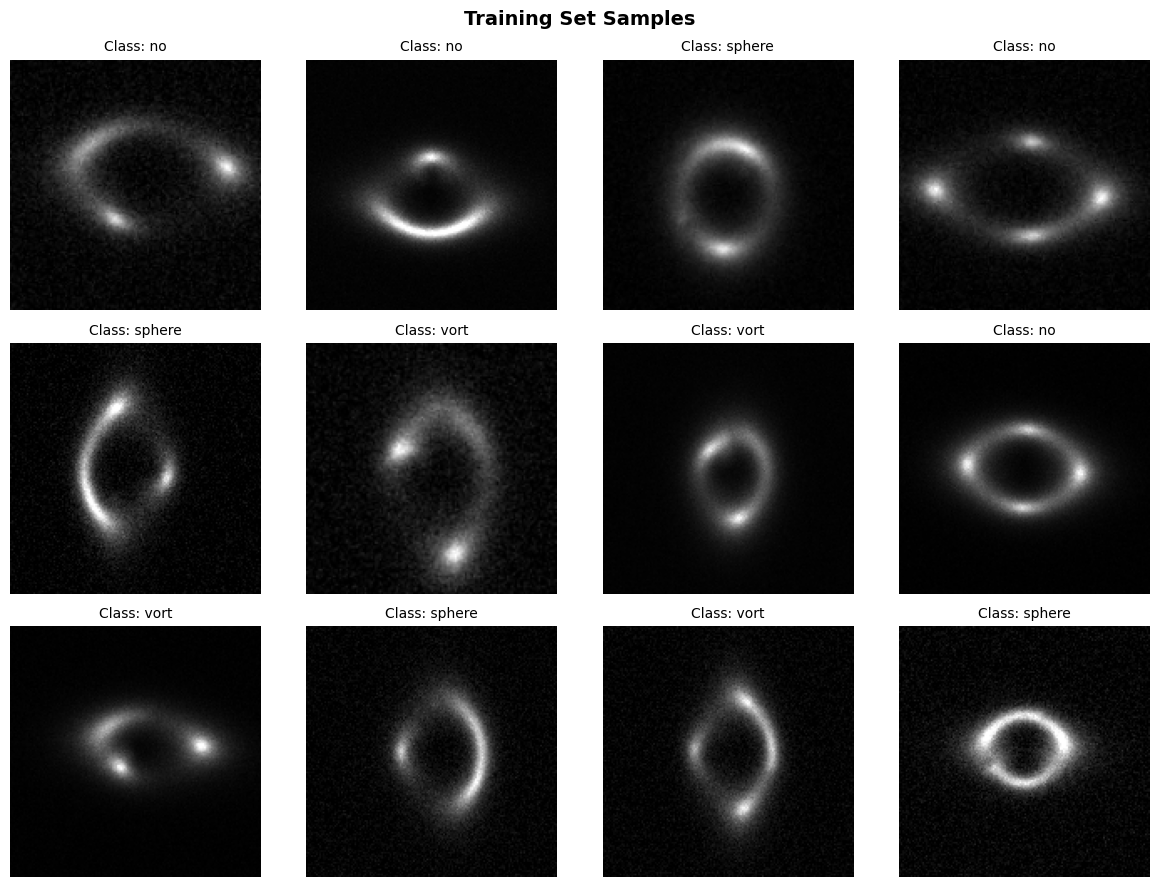

In [7]:
# ============================================================
# Data Loading (NPY files)
# ============================================================

import numpy as np
from torch.utils.data import Dataset
from PIL import Image

class NPYImageFolder(Dataset):
    """Custom dataset for loading .npy files organized in class folders"""
    
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.samples = []
        self.classes = sorted([d for d in os.listdir(root_dir) 
                               if os.path.isdir(os.path.join(root_dir, d))])
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}
        
        # Collect all .npy files
        for class_name in self.classes:
            class_dir = os.path.join(root_dir, class_name)
            for filename in os.listdir(class_dir):
                if filename.endswith('.npy'):
                    filepath = os.path.join(class_dir, filename)
                    self.samples.append((filepath, self.class_to_idx[class_name]))
        
        print(f"   Found {len(self.samples)} samples in {root_dir}")
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        filepath, label = self.samples[idx]
        
        # Load numpy array
        arr = np.load(filepath)
        
        # Handle different shapes
        if arr.ndim == 2:
            # (H, W) -> add channel dimension
            arr = arr[np.newaxis, :, :]
        elif arr.ndim == 3 and arr.shape[0] not in [1, 3]:
            # (H, W, C) -> (C, H, W)
            arr = arr.transpose(2, 0, 1)
        
        # Normalize to [0, 1] if needed
        if arr.max() > 1.0:
            arr = arr / 255.0
        
        # Convert to tensor
        tensor = torch.from_numpy(arr).float()
        
        # Apply transforms if any
        if self.transform:
            tensor = self.transform(tensor)
        
        return tensor, label


class NPYTransform:
    """Transforms for tensor data with enhanced augmentation to reduce overfitting"""
    
    def __init__(self, img_size, augment=False):
        self.img_size = img_size
        self.augment = augment
    
    def __call__(self, x):
        # Resize if needed
        if x.shape[-1] != self.img_size or x.shape[-2] != self.img_size:
            x = F.interpolate(x.unsqueeze(0), size=(self.img_size, self.img_size), 
                             mode='bilinear', align_corners=False).squeeze(0)
        
        # Enhanced Augmentation for training
        if self.augment:
            # 1. Random horizontal flip (50% probability)
            if torch.rand(1) > 0.5:
                x = torch.flip(x, dims=[-1])
            
            # 2. Random vertical flip (50% probability)
            if torch.rand(1) > 0.5:
                x = torch.flip(x, dims=[-2])
            
            # 3. Random 90-degree rotations (0, 90, 180, 270 degrees)
            k = torch.randint(0, 4, (1,)).item()  # 0, 1, 2, or 3
            if k > 0:
                x = torch.rot90(x, k, dims=[-2, -1])
            
            # 4. Random Gaussian noise (helps with generalization)
            if torch.rand(1) > 0.5:
                noise_std = torch.rand(1).item() * 0.05  # Random noise level 0-5%
                noise = torch.randn_like(x) * noise_std
                x = x + noise
                x = torch.clamp(x, 0, 1)  # Keep values in valid range
            
            # 5. Random brightness adjustment
            if torch.rand(1) > 0.5:
                brightness_factor = 0.8 + torch.rand(1).item() * 0.4  # 0.8 to 1.2
                x = x * brightness_factor
                x = torch.clamp(x, 0, 1)
            
            # 6. Random contrast adjustment
            if torch.rand(1) > 0.5:
                contrast_factor = 0.8 + torch.rand(1).item() * 0.4  # 0.8 to 1.2
                mean = x.mean()
                x = (x - mean) * contrast_factor + mean
                x = torch.clamp(x, 0, 1)
            
            # 7. Random center crop and resize (zoom effect)
            if torch.rand(1) > 0.7:  # 30% probability
                crop_ratio = 0.8 + torch.rand(1).item() * 0.15  # Crop 80-95% of image
                crop_size = int(self.img_size * crop_ratio)
                start = (self.img_size - crop_size) // 2
                x = x[:, start:start+crop_size, start:start+crop_size]
                x = F.interpolate(x.unsqueeze(0), size=(self.img_size, self.img_size),
                                 mode='bilinear', align_corners=False).squeeze(0)
        
        # Normalize to [-1, 1]
        x = (x - 0.5) / 0.5
        
        return x


from torch.utils.data import random_split
import matplotlib.pyplot as plt

def get_dataloaders(config, test_split=0.15):
    """Create train, validation, and test dataloaders with test split from validation"""
    train_transform = NPYTransform(config["img_size"], augment=True)
    val_transform = NPYTransform(config["img_size"], augment=False)
    
    train_dataset = NPYImageFolder(config["train_dir"], train_transform)
    val_full_dataset = NPYImageFolder(config["val_dir"], val_transform)
    
    # Split validation into val and test sets
    total_val = len(val_full_dataset)
    test_size = int(total_val * test_split)
    val_size = total_val - test_size
    
    val_dataset, test_dataset = random_split(
        val_full_dataset, 
        [val_size, test_size],
        generator=torch.Generator().manual_seed(42)  # For reproducibility
    )
    
    train_loader = DataLoader(
        train_dataset, 
        batch_size=config["batch_size"],
        shuffle=True, 
        num_workers=config["num_workers"],
        pin_memory=True,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=config["batch_size"],
        shuffle=False,
        num_workers=config["num_workers"],
        pin_memory=True,
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=config["batch_size"],
        shuffle=False,
        num_workers=config["num_workers"],
        pin_memory=True,
    )
    
    return train_loader, val_loader, test_loader, train_dataset.classes


def plot_sample_images(loader, classes, num_samples=12, title="Sample Images"):
    """Plot sample images from a dataloader"""
    images, labels = next(iter(loader))
    
    # Denormalize images (from [-1,1] to [0,1])
    images = images * 0.5 + 0.5
    
    num_samples = min(num_samples, len(images))
    cols = 4
    rows = (num_samples + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(12, 3*rows))
    axes = axes.flatten() if num_samples > 1 else [axes]
    
    for i in range(num_samples):
        img = images[i].squeeze().numpy()
        label = labels[i].item()
        
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f'Class: {classes[label]}', fontsize=10)
        axes[i].axis('off')
    
    # Hide empty subplots
    for i in range(num_samples, len(axes)):
        axes[i].axis('off')
    
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


# Load data
print("📂 Loading NPY dataset...")
train_loader, val_loader, test_loader, classes = get_dataloaders(CONFIG)

print(f"\n✅ Data loaded:")
print(f"   Train samples: {len(train_loader.dataset)}")
print(f"   Val samples: {len(val_loader.dataset)}")
print(f"   Test samples: {len(test_loader.dataset)}")
print(f"   Classes: {classes}")
print(f"   Batch size: {CONFIG['batch_size']}")

# Verify a sample
sample_batch, sample_labels = next(iter(train_loader))
print(f"\n📊 Sample batch shape: {sample_batch.shape}")
print(f"   Expected: [batch_size, 1, 150, 150]")

# Plot sample images from training set
print("\n🖼️ Sample Training Images:")
plot_sample_images(train_loader, classes, num_samples=12, title="Training Set Samples")

In [8]:
# ============================================================
# Training Functions 
# ============================================================

import copy
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle

def plot_roc_curve(all_labels, all_probs, class_names, save_path="roc_curve.png"):
    """Plots the ROC curve for each class and micro/macro averages."""
    all_labels_bin = label_binarize(all_labels, classes=range(len(class_names)))
    all_probs = np.array(all_probs)

    fpr, tpr, roc_auc = {}, {}, {}
    
    for i in range(len(class_names)):
        fpr[i], tpr[i], _ = roc_curve(all_labels_bin[:, i], all_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Micro-average
    fpr["micro"], tpr["micro"], _ = roc_curve(all_labels_bin.ravel(), all_probs.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    # Macro-average
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(len(class_names))]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(len(class_names)):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= len(class_names)
    fpr["macro"], tpr["macro"] = all_fpr, mean_tpr
    roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

    # Plot
    plt.figure(figsize=(10, 8))
    plt.plot(fpr["micro"], tpr["micro"],
             label=f'micro-average (AUC = {roc_auc["micro"]:.4f})',
             color='deeppink', linestyle=':', linewidth=4)
    plt.plot(fpr["macro"], tpr["macro"],
             label=f'macro-average (AUC = {roc_auc["macro"]:.4f})',
             color='navy', linestyle=':', linewidth=4)

    colors = ['#2ecc71', '#3498db', '#e74c3c']
    for i, color in zip(range(len(class_names)), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f'{class_names[i]} (AUC = {roc_auc[i]:.4f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('Multi-class ROC Curve', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"ROC curve saved to {save_path}")
    
    return roc_auc


def train_model_healswin_style(model, train_loader, val_loader, criterion, optimizer, 
                                scheduler, config, device, class_names):
    """
    HEALSwin-PINN style training with:
    - ROC AUC as primary metric
    - Warmup + Cosine Annealing LR
    - Label smoothing
    - Strong regularization
    """
    
    num_epochs = config["epochs"]
    patience = config.get("patience", 100)
    prior_weight = config.get("prior_weight", 0.0)
    opt_weight = config.get("opt_weight", 0.0)
    
    print(f"\n{'='*60}")
    print(f"Training Configuration:")
    print(f"   Device: {device}")
    print(f"   Epochs: {num_epochs}, Patience: {patience}")
    print(f"   Prior weight: {prior_weight}, Opt weight: {opt_weight}")
    print(f"{'='*60}\n")
    
    model.to(device)

    best_roc_auc = 0.0
    best_val_acc = 0.0
    epochs_no_improve = 0
    best_model_wts = copy.deepcopy(model.state_dict())
    best_probs, best_labels = [], []
    history = []

    for epoch in range(num_epochs):
        # =============== TRAINING PHASE ===============
        model.train()
        train_loss, train_ce, train_prior, train_opt = 0.0, 0.0, 0.0, 0.0
        train_correct, train_total = 0, 0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]", leave=False)
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            
            # Losses
            ce_loss = criterion(outputs, labels)
            prior_loss = model.get_prior_loss()
            opt_loss = model.get_optimization_loss()
            
            loss = ce_loss + prior_weight * prior_loss + opt_weight * opt_loss
            
            loss.backward()
            
            # Gradient clipping (stabilizes training)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()

            # Accumulate metrics
            train_loss += loss.item() * images.size(0)
            train_ce += ce_loss.item() * images.size(0)
            train_prior += prior_loss.item() * images.size(0)
            train_opt += (opt_loss.item() if isinstance(opt_loss, torch.Tensor) else opt_loss) * images.size(0)
            
            _, predicted = torch.max(outputs, 1)
            train_correct += (predicted == labels).sum().item()
            train_total += labels.size(0)
            
            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'acc': f'{100*train_correct/train_total:.1f}%'
            })

        # Step scheduler AFTER epoch
        scheduler.step()

        # =============== VALIDATION PHASE ===============
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        all_probs, all_labels_list = [], []

        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]", leave=False):
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)

                probs = torch.softmax(outputs, dim=1)
                all_probs.extend(probs.cpu().numpy())
                all_labels_list.extend(labels.cpu().numpy())

        # =============== CALCULATE METRICS ===============
        train_loss /= train_total
        train_ce /= train_total
        train_acc = 100 * train_correct / train_total
        
        val_loss /= val_total
        val_acc = 100 * val_correct / val_total

        # ROC AUC
        try:
            val_roc_auc = roc_auc_score(
                np.array(all_labels_list), 
                np.array(all_probs), 
                multi_class='ovr', 
                average='macro'
            )
        except ValueError:
            val_roc_auc = 0.0

        current_lr = scheduler.get_last_lr()[0]
        
        # Save history
        history.append({
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'train_ce': train_ce,
            'train_acc': train_acc,
            'val_loss': val_loss,
            'val_acc': val_acc,
            'val_roc_auc': val_roc_auc,
            'lr': current_lr
        })

        # =============== CHECK FOR IMPROVEMENT ===============
        # Use ROC AUC as primary metric (better for imbalanced data)
        improved = val_roc_auc > best_roc_auc
        
        if improved:
            best_roc_auc = val_roc_auc
            best_val_acc = val_acc
            epochs_no_improve = 0
            best_model_wts = copy.deepcopy(model.state_dict())
            best_probs = all_probs
            best_labels = all_labels_list
            
            # Save checkpoint
            os.makedirs(config["save_dir"], exist_ok=True)
            save_path = os.path.join(config["save_dir"], 
                                     f"best_{config['canon_network']}_{config['backbone']}.pth")
            torch.save({
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'val_roc_auc': best_roc_auc,
                'val_acc': best_val_acc,
                'epoch': epoch + 1,
                'config': config,
                'history': history,
            }, save_path)
            
            status = "✅ NEW BEST"
        else:
            epochs_no_improve += 1
            status = f"⏳ No improve ({epochs_no_improve}/{patience})"

        # =============== LOGGING ===============
        print(f"\nEpoch {epoch+1}/{num_epochs} | LR: {current_lr:.6f} | {status}")
        print(f"  Train: loss={train_loss:.4f}, ce={train_ce:.4f}, acc={train_acc:.2f}%")
        print(f"  Val:   loss={val_loss:.4f}, acc={val_acc:.2f}%, ROC-AUC={val_roc_auc:.4f}")
        print(f"  Best:  ROC-AUC={best_roc_auc:.4f}, acc={best_val_acc:.2f}%")

        # Early stopping
        if epochs_no_improve >= patience:
            print(f"\n⚠️ Early stopping at epoch {epoch+1}")
            break

    # =============== TRAINING COMPLETE ===============
    print("\n" + "="*60)
    print("🎉 Training Complete!")
    print(f"   Best ROC AUC: {best_roc_auc:.4f}")
    print(f"   Best Val Accuracy: {best_val_acc:.2f}%")
    print("="*60)
    
    # Load best model
    model.load_state_dict(best_model_wts)

    # Plot final ROC curve
    if best_probs and best_labels:
        save_path = os.path.join(config["save_dir"], "roc_curve_best.png")
        plot_roc_curve(best_labels, best_probs, class_names, save_path)

    return model, history, best_probs, best_labels


print("✅  style training functions defined")

✅  style training functions defined


In [9]:
# ============================================================
# Create Model
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️  Device: {device}")

# Create model
model = LensingClassifier(CONFIG).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
canon_params = sum(p.numel() for p in model.canon_network.parameters() if p.requires_grad)
backbone_params = sum(p.numel() for p in model.backbone.parameters() if p.requires_grad)

print(f"\n🏗️  Model created:")
print(f"   Canonicalization: {CONFIG['canon_network']}")
print(f"   Backbone: {CONFIG['backbone']}")
print(f"   Group: {CONFIG['group_type']} with {CONFIG['num_rotations']} rotations")
print(f"\n📊 Parameters:")
print(f"   Canonicalizer: {canon_params:,}")
print(f"   Backbone: {backbone_params:,}")
print(f"   Total: {total_params:,}")

# Print full model architecture
print("\n" + "="*70)
print("                      MODEL ARCHITECTURE")
print("="*70)
print(model)
print("="*70)

# Detailed layer-by-layer summary
def print_model_summary(model, input_size=(1, 1, 150, 150)):
    """Print a detailed summary of model layers and parameters"""
    print("\n" + "="*70)
    print("                    LAYER-BY-LAYER SUMMARY")
    print("="*70)
    print(f"{'Layer Name':<50} {'Output Shape':<20} {'Params':>12}")
    print("-"*70)
    
    total = 0
    trainable = 0
    
    for name, module in model.named_modules():
        if len(list(module.children())) == 0:  # Leaf modules only
            params = sum(p.numel() for p in module.parameters())
            train_params = sum(p.numel() for p in module.parameters() if p.requires_grad)
            if params > 0:
                total += params
                trainable += train_params
                name_short = name[-48:] if len(name) > 48 else name
                print(f"{name_short:<50} {'':<20} {params:>12,}")
    
    print("-"*70)
    print(f"{'Total Parameters:':<50} {'':<20} {total:>12,}")
    print(f"{'Trainable Parameters:':<50} {'':<20} {trainable:>12,}")
    print(f"{'Non-trainable Parameters:':<50} {'':<20} {total-trainable:>12,}")
    print("="*70)
    
    # Memory estimation
    param_size_mb = total * 4 / (1024**2)  # Assuming float32
    print(f"\n💾 Estimated Model Size: {param_size_mb:.2f} MB")

print_model_summary(model)

🖥️  Device: cuda


/home/jovyan/.local/lib/python3.11/site-packages/e2cnn/nn/modules/r2_conv/basisexpansion_singleblock.py:80: UserWarning: indexing with dtype torch.uint8 is now deprecated, please use a dtype torch.bool instead. (Triggered internally at ../aten/src/ATen/native/IndexingUtils.h:27.)
  full_mask[mask] = norms.to(torch.uint8)



🏗️  Model created:
   Canonicalization: ESCNNEquivariantNetwork
   Backbone: resnet18
   Group: rotation with 8 rotations

📊 Parameters:
   Canonicalizer: 295,712
   Backbone: 11,171,779
   Total: 11,467,491

                      MODEL ARCHITECTURE
LensingClassifier(
  (canon_network): ESCNNEquivariantNetwork(
    (eqv_network): SequentialModule(
      (0): R2Conv([8-Rotations: {irrep_0}], [8-Rotations: {regular, regular, regular, regular, regular, regular, regular, regular, regular, regular, regular, regular, regular, regular, regular, regular, regular, regular, regular, regular, regular, regular, regular, regular, regular, regular, regular, regular, regular, regular, regular, regular}], kernel_size=7, stride=1)
      (1): InnerBatchNorm([8-Rotations: {regular, regular, regular, regular, regular, regular, regular, regular, regular, regular, regular, regular, regular, regular, regular, regular, regular, regular, regular, regular, regular, regular, regular, regular, regular, regular, 

In [10]:
# ============================================================
# Setup Optimizer and Scheduler
# ============================================================

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CONFIG["lr"],
    weight_decay=CONFIG["weight_decay"],
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, 
    T_max=CONFIG["epochs"]
)

print(f"✅ Optimizer: AdamW (lr={CONFIG['lr']}, weight_decay={CONFIG['weight_decay']})")
print(f"✅ Scheduler: CosineAnnealingLR (T_max={CONFIG['epochs']})")

✅ Optimizer: AdamW (lr=0.0001, weight_decay=0.05)
✅ Scheduler: CosineAnnealingLR (T_max=150)


🖥️  Device: cuda

📊 Parameters:
   Canonicalizer: 295,712
   Backbone: 11,171,779
   Total: 11,467,491

⚙️ Training Setup:
   Optimizer: AdamW (lr=0.0001, wd=0.05)
   Scheduler: Warmup (10ep) + CosineAnnealing
   Loss: CE with label_smoothing=0.1
   Gradient clipping: max_norm=1.0

🚀 Starting training...

Training Configuration:
   Device: cuda
   Epochs: 150, Patience: 30
   Prior weight: 0.2, Opt weight: 0.15



Epoch 1/150 [Train]:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 1/150 [Val]:   0%|          | 0/100 [00:00<?, ?it/s]


Epoch 1/150 | LR: 0.000020 | ✅ NEW BEST
  Train: loss=1.5190, ce=1.1032, acc=33.11%
  Val:   loss=1.0983, acc=34.95%, ROC-AUC=0.5200
  Best:  ROC-AUC=0.5200, acc=34.95%


Epoch 2/150 [Train]:   0%|          | 0/469 [00:00<?, ?it/s]

...

Epoch 149/150 [Val]:   0%|          | 0/100 [00:00<?, ?it/s]


Epoch 149/150 | LR: 0.000001 | ⏳ No improve (18/30)
  Train: loss=0.7215, ce=0.4400, acc=91.68%
  Val:   loss=0.4099, acc=93.96%, ROC-AUC=0.9878
  Best:  ROC-AUC=0.9882, acc=93.71%


Epoch 150/150 [Train]:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 150/150 [Val]:   0%|          | 0/100 [00:00<?, ?it/s]


Epoch 150/150 | LR: 0.000001 | ⏳ No improve (19/30)
  Train: loss=0.7254, ce=0.4442, acc=91.48%
  Val:   loss=0.4098, acc=93.93%, ROC-AUC=0.9878
  Best:  ROC-AUC=0.9882, acc=93.71%

🎉 Training Complete!
   Best ROC AUC: 0.9882
   Best Val Accuracy: 93.71%


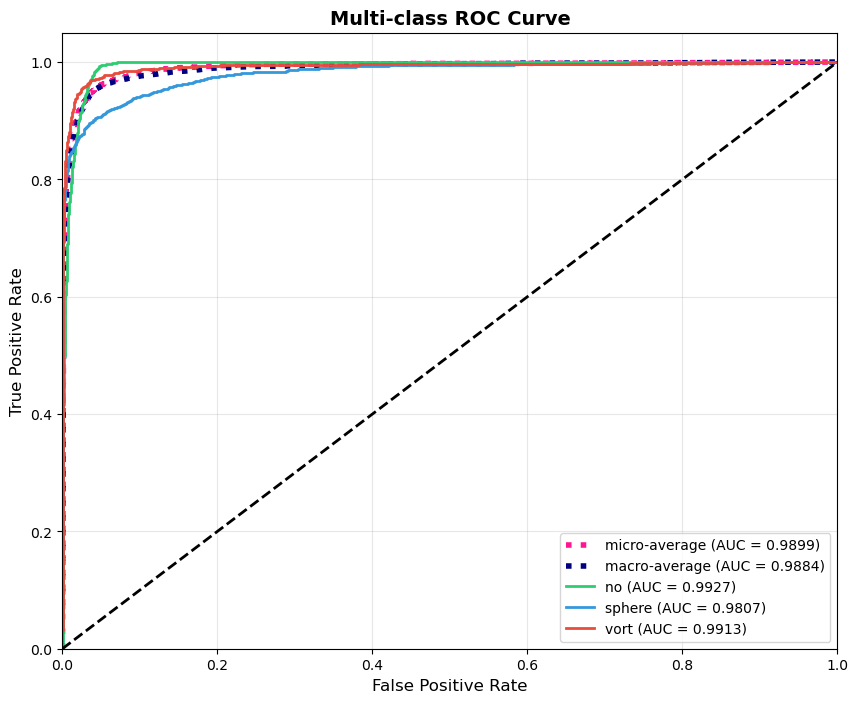

ROC curve saved to ./checkpoints/roc_curve_best.png


In [10]:
# ============================================================
# Setup and Train
# ============================================================

from torch.optim.lr_scheduler import LambdaLR, CosineAnnealingLR, SequentialLR

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️  Device: {device}")

# Create model
model = LensingClassifier(CONFIG).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
canon_params = sum(p.numel() for p in model.canon_network.parameters() if p.requires_grad)
backbone_params = sum(p.numel() for p in model.backbone.parameters() if p.requires_grad)

print(f"\n📊 Parameters:")
print(f"   Canonicalizer: {canon_params:,}")
print(f"   Backbone: {backbone_params:,}")
print(f"   Total: {total_params:,}")

# Loss with label smoothing
criterion = nn.CrossEntropyLoss(label_smoothing=CONFIG["label_smoothing"])

# Optimizer
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CONFIG["lr"],
    weight_decay=CONFIG["weight_decay"]
)

# Scheduler: Warmup + CosineAnnealing
warmup_epochs = CONFIG["warmup_epochs"]
num_epochs = CONFIG["epochs"]

def warmup_lambda(epoch):
    if epoch < warmup_epochs:
        return float(epoch + 1) / float(max(1, warmup_epochs))
    return 1.0

warmup_scheduler = LambdaLR(optimizer, lr_lambda=warmup_lambda)
main_scheduler = CosineAnnealingLR(
    optimizer, 
    T_max=num_epochs - warmup_epochs, 
    eta_min=1e-6
)
scheduler = SequentialLR(
    optimizer, 
    schedulers=[warmup_scheduler, main_scheduler], 
    milestones=[warmup_epochs]
)

print(f"\n⚙️ Training Setup:")
print(f"   Optimizer: AdamW (lr={CONFIG['lr']}, wd={CONFIG['weight_decay']})")
print(f"   Scheduler: Warmup ({warmup_epochs}ep) + CosineAnnealing")
print(f"   Loss: CE with label_smoothing={CONFIG['label_smoothing']}")
print(f"   Gradient clipping: max_norm=1.0")

# Train
print("\n🚀 Starting training...")
model, history, all_probs, all_labels = train_model_healswin_style(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    config=CONFIG,
    device=device,
    class_names=classes
)

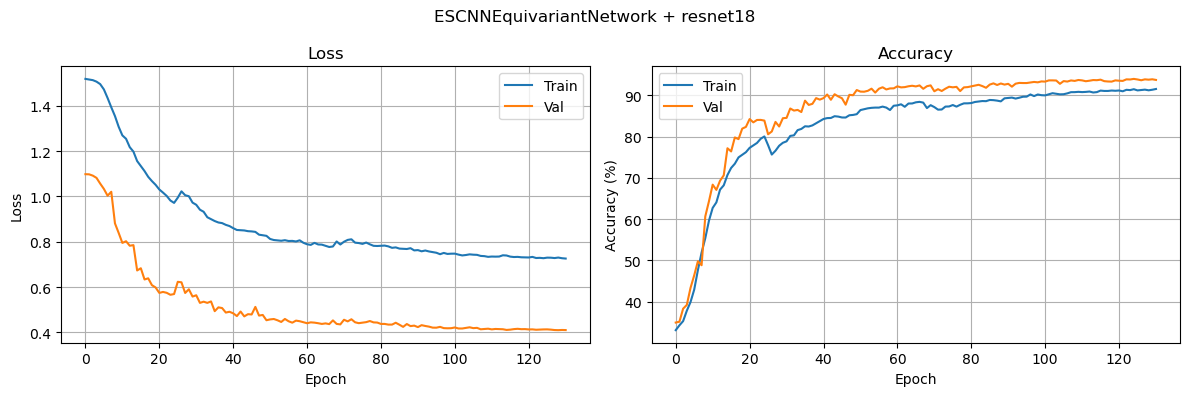


📊 Final Results:
   Best Val Accuracy: 93.96%
   Final Train Accuracy: 91.52%


In [13]:
# ============================================================
# Plot Training History
# ============================================================

import matplotlib.pyplot as plt
import os

# Load history from checkpoint if not already in memory
try:
    _ = history  # Check if history exists
except NameError:
    # Load from checkpoint
    checkpoint_path = os.path.join(CONFIG["save_dir"], f"best_{CONFIG['canon_network']}_{CONFIG['backbone']}.pth")
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    history = checkpoint['history']
    print(f"📥 Loaded history from checkpoint (epoch {checkpoint['epoch']})")

# Calculate best_acc from history
best_acc = max(h['val_acc'] for h in history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss plot
axes[0].plot([h['train_loss'] for h in history], label='Train')
axes[0].plot([h['val_loss'] for h in history], label='Val')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy plot
axes[1].plot([h['train_acc'] for h in history], label='Train')
axes[1].plot([h['val_acc'] for h in history], label='Val')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.suptitle(f"{CONFIG['canon_network']} + {CONFIG['backbone']}")
plt.tight_layout()
plt.show()

print(f"\n📊 Final Results:")
print(f"   Best Val Accuracy: {best_acc:.2f}%")
print(f"   Final Train Accuracy: {history[-1]['train_acc']:.2f}%")




In [14]:
# ============================================================
# TEST SET EVALUATION - FIXED
# ============================================================

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

@torch.no_grad()
def evaluate_on_test(model, test_loader, device, classes):
    """Comprehensive evaluation on test set"""
    model.eval()
    
    all_preds = []
    all_labels = []
    all_probs = []
    all_images = []
    total_loss = 0
    
    print("🧪 Evaluating on test set...")
    for images, labels in tqdm(test_loader, desc="Testing"):
        images, labels = images.to(device), labels.to(device)
        
        logits = model(images)
        loss = F.cross_entropy(logits, labels)
        probs = F.softmax(logits, dim=1)
        
        _, preds = logits.max(1)
        
        total_loss += loss.item()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_images.extend(images.cpu())
    
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    
    # Calculate metrics
    accuracy = 100 * (all_preds == all_labels).sum() / len(all_labels)
    avg_loss = total_loss / len(test_loader)
    
    return {
        'accuracy': accuracy,
        'loss': avg_loss,
        'predictions': all_preds,
        'labels': all_labels,
        'probabilities': all_probs,
        'images': all_images
    }

# Load best model
print("📥 Loading best model...")
checkpoint_path = os.path.join(CONFIG["save_dir"], f"best_{CONFIG['canon_network']}_{CONFIG['backbone']}.pth")

# Fix 1: Add weights_only=True to suppress the FutureWarning (optional but recommended)
# Fix 2: Use strict=False to handle ESCNN's dynamic parameters
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)

# Load with strict=False to ignore extra ESCNN cached parameters
load_result = model.load_state_dict(checkpoint['model_state_dict'], strict=False)

# Print what was loaded/skipped
print(f"   Loaded model from epoch {checkpoint['epoch']}")
print(f"   Val ROC-AUC: {checkpoint.get('val_roc_auc', 'N/A')}")
print(f"   Val Accuracy: {checkpoint.get('val_acc', 'N/A'):.2f}%")

if load_result.missing_keys:
    print(f"   ⚠️ Missing keys (OK if empty): {len(load_result.missing_keys)}")
if load_result.unexpected_keys:
    print(f"   ℹ️ Unexpected keys (ESCNN cache, safe to ignore): {len(load_result.unexpected_keys)}")

# Evaluate on test set
test_results = evaluate_on_test(model, test_loader, device, classes)

print(f"\n" + "="*60)
print(f"🎯 TEST SET RESULTS")
print(f"="*60)
print(f"   Test Accuracy: {test_results['accuracy']:.2f}%")
print(f"   Test Loss: {test_results['loss']:.4f}")
print(f"="*60)

📥 Loading best model...
   Loaded model from epoch 131
   Val ROC-AUC: 0.9882433404265966
   Val Accuracy: 93.71%
🧪 Evaluating on test set...


Testing:   0%|          | 0/18 [00:00<?, ?it/s]


🎯 TEST SET RESULTS
   Test Accuracy: 93.96%
   Test Loss: 0.2119


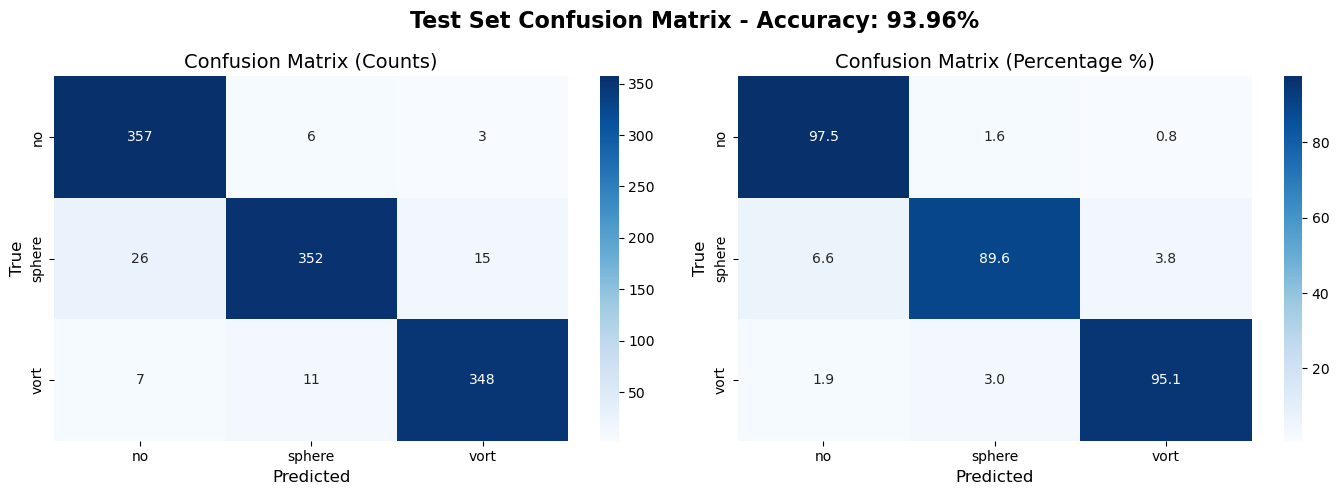


📊 Classification Report:
              precision    recall  f1-score   support

          no     0.9154    0.9754    0.9444       366
      sphere     0.9539    0.8957    0.9239       393
        vort     0.9508    0.9508    0.9508       366

    accuracy                         0.9396      1125
   macro avg     0.9400    0.9406    0.9397      1125
weighted avg     0.9404    0.9396    0.9393      1125



In [15]:
# ============================================================
# CONFUSION MATRIX VISUALIZATION
# ============================================================

# Compute confusion matrix
cm = confusion_matrix(test_results['labels'], test_results['predictions'])
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes, ax=axes[0])
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('True', fontsize=12)
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14)

# Normalized percentages
sns.heatmap(cm_normalized, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=classes, yticklabels=classes, ax=axes[1])
axes[1].set_xlabel('Predicted', fontsize=12)
axes[1].set_ylabel('True', fontsize=12)
axes[1].set_title('Confusion Matrix (Percentage %)', fontsize=14)

plt.suptitle(f'Test Set Confusion Matrix - Accuracy: {test_results["accuracy"]:.2f}%', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Classification Report
print("\n📊 Classification Report:")
print("="*60)
print(classification_report(test_results['labels'], test_results['predictions'], 
                           target_names=classes, digits=4))

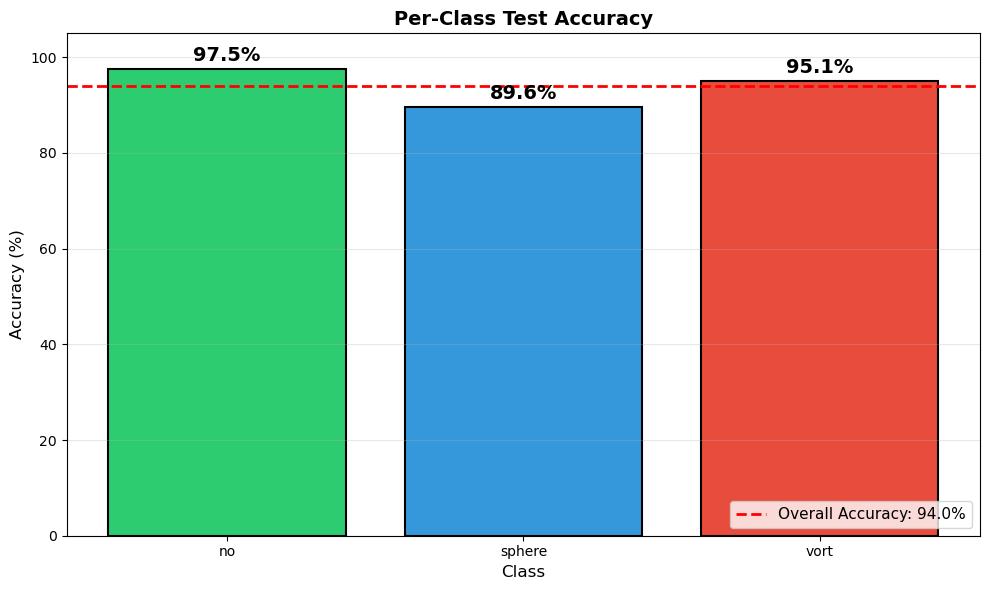

In [16]:
# ============================================================
# PER-CLASS ACCURACY VISUALIZATION
# ============================================================

# Calculate per-class accuracy
per_class_acc = cm.diagonal() / cm.sum(axis=1) * 100

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#2ecc71', '#3498db', '#e74c3c']
bars = ax.bar(classes, per_class_acc, color=colors, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bar, acc in zip(bars, per_class_acc):
    height = bar.get_height()
    ax.annotate(f'{acc:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=14, fontweight='bold')

ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_xlabel('Class', fontsize=12)
ax.set_title('Per-Class Test Accuracy', fontsize=14, fontweight='bold')
ax.set_ylim(0, 105)
ax.axhline(y=test_results['accuracy'], color='red', linestyle='--', 
           label=f'Overall Accuracy: {test_results["accuracy"]:.1f}%', linewidth=2)
ax.legend(loc='lower right', fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


🖼️ Random Sample Predictions:


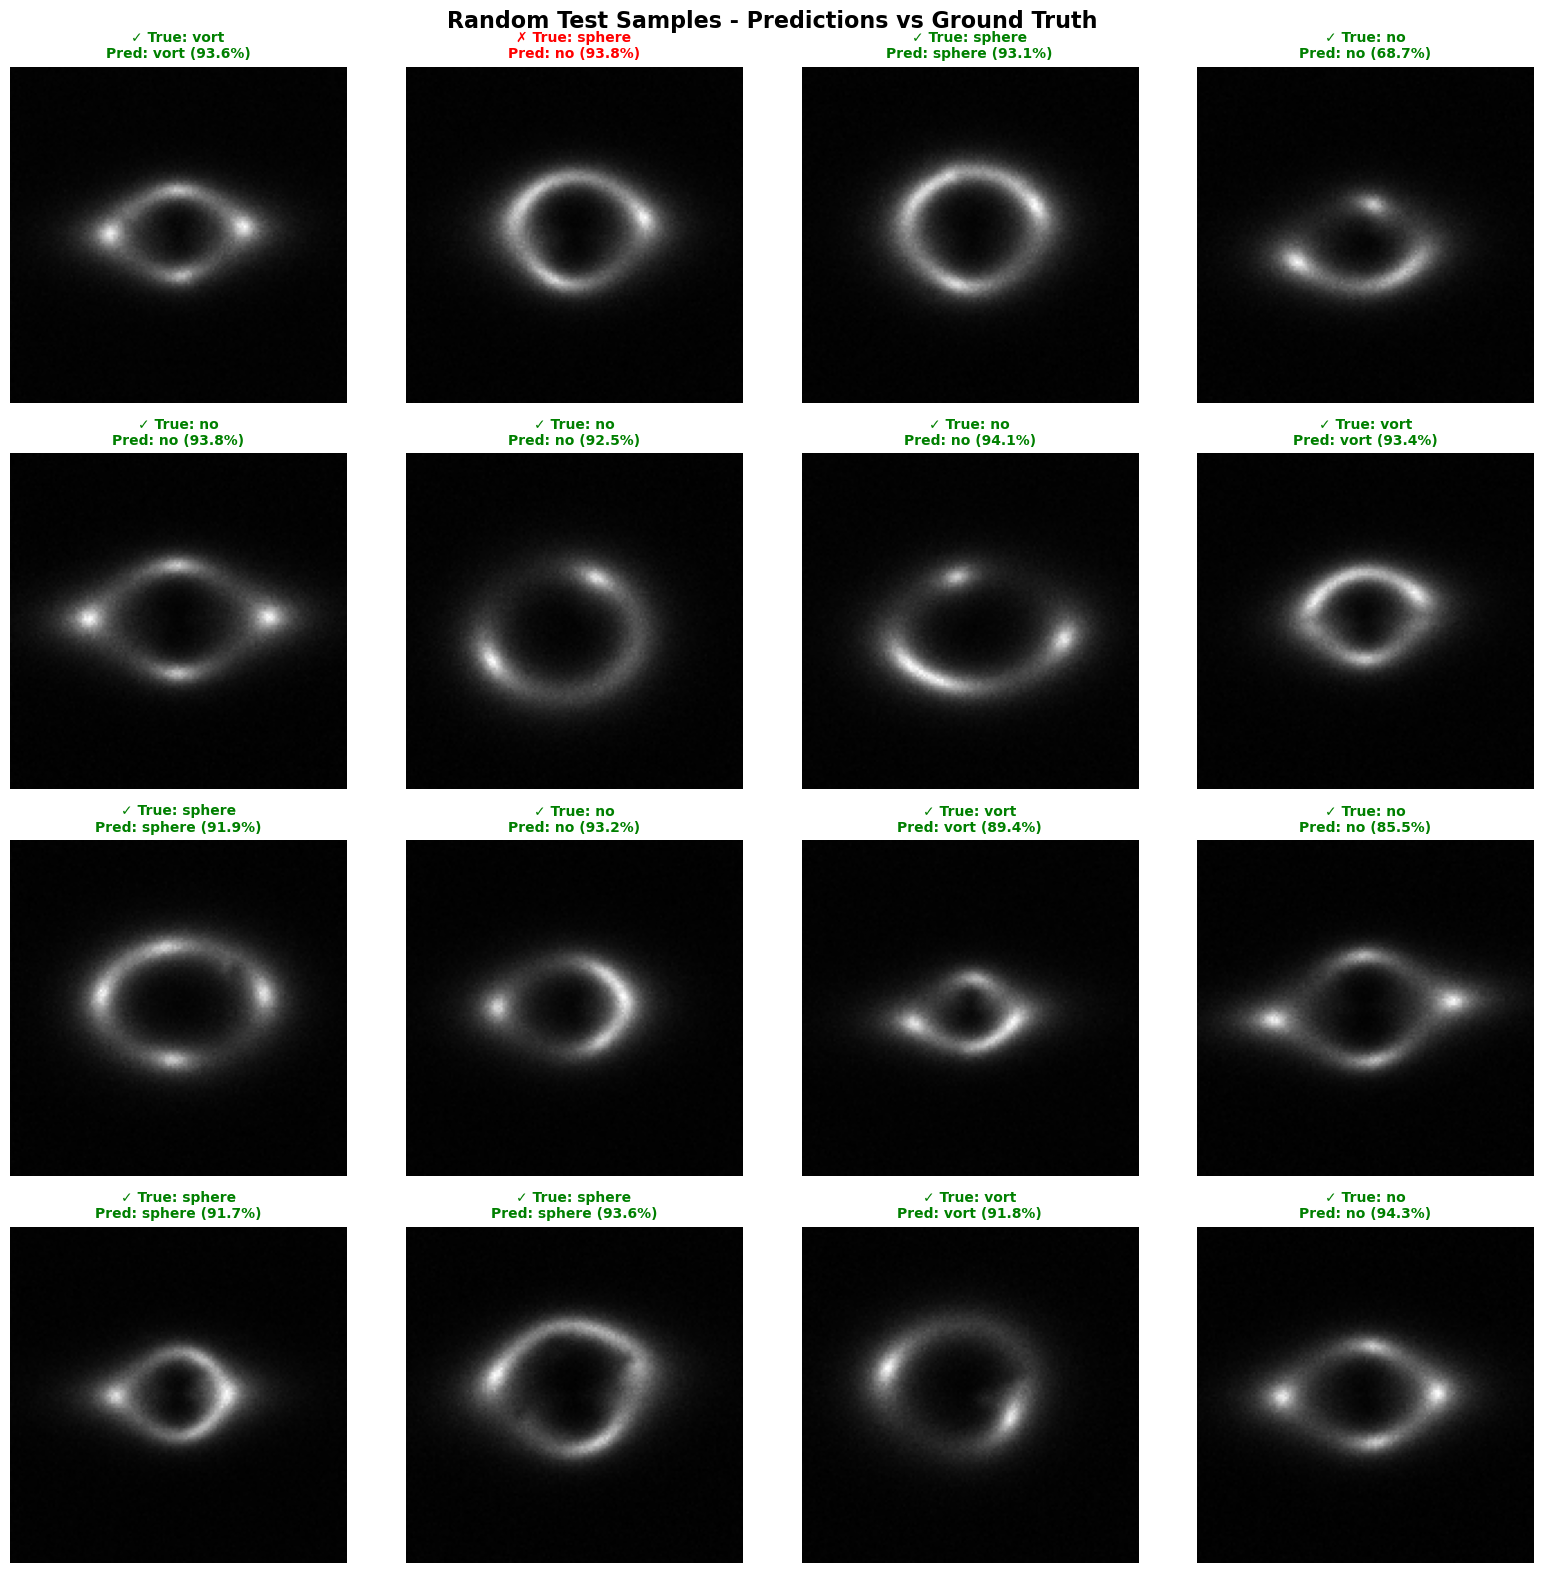

In [17]:
# ============================================================
# PREDICTIONS VS GROUND TRUTH VISUALIZATION
# ============================================================

def plot_predictions_grid(images, labels, predictions, probs, classes, 
                          num_samples=16, title="Predictions vs Ground Truth"):
    """Plot a grid of images with predictions and ground truth"""
    num_samples = min(num_samples, len(images))
    cols = 4
    rows = (num_samples + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(16, 4*rows))
    axes = axes.flatten()
    
    for i in range(num_samples):
        # Denormalize image
        img = images[i].squeeze().numpy() * 0.5 + 0.5
        true_label = labels[i]
        pred_label = predictions[i]
        confidence = probs[i][pred_label] * 100
        
        # Determine if prediction is correct
        is_correct = true_label == pred_label
        
        axes[i].imshow(img, cmap='gray')
        
        # Color-coded title
        color = 'green' if is_correct else 'red'
        status = '✓' if is_correct else '✗'
        
        title_text = f'{status} True: {classes[true_label]}\nPred: {classes[pred_label]} ({confidence:.1f}%)'
        axes[i].set_title(title_text, fontsize=10, color=color, fontweight='bold')
        axes[i].axis('off')
        
        # Add border
        for spine in axes[i].spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(3)
    
    # Hide empty subplots
    for i in range(num_samples, len(axes)):
        axes[i].axis('off')
    
    plt.suptitle(title, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()


# Get random samples
np.random.seed(42)
random_indices = np.random.choice(len(test_results['images']), size=16, replace=False)

sample_images = [test_results['images'][i] for i in random_indices]
sample_labels = test_results['labels'][random_indices]
sample_preds = test_results['predictions'][random_indices]
sample_probs = test_results['probabilities'][random_indices]

print("\n🖼️ Random Sample Predictions:")
plot_predictions_grid(sample_images, sample_labels, sample_preds, sample_probs, 
                      classes, num_samples=16, title="Random Test Samples - Predictions vs Ground Truth")


📊 Prediction Statistics:
   Correct predictions: 1057 (94.0%)
   Incorrect predictions: 68 (6.0%)

✅ Sample CORRECT Predictions:


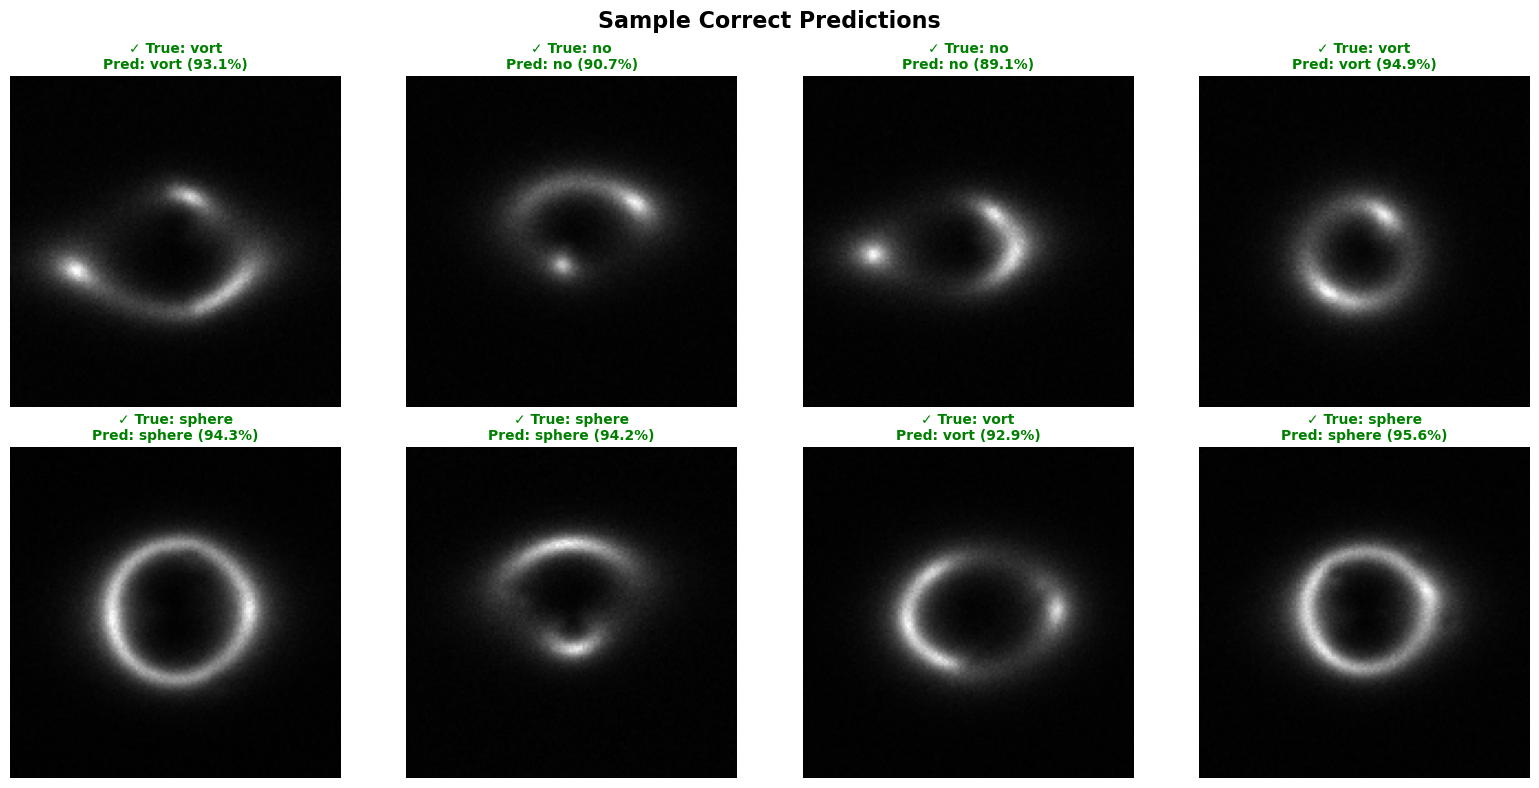


❌ Sample INCORRECT Predictions (Misclassifications):


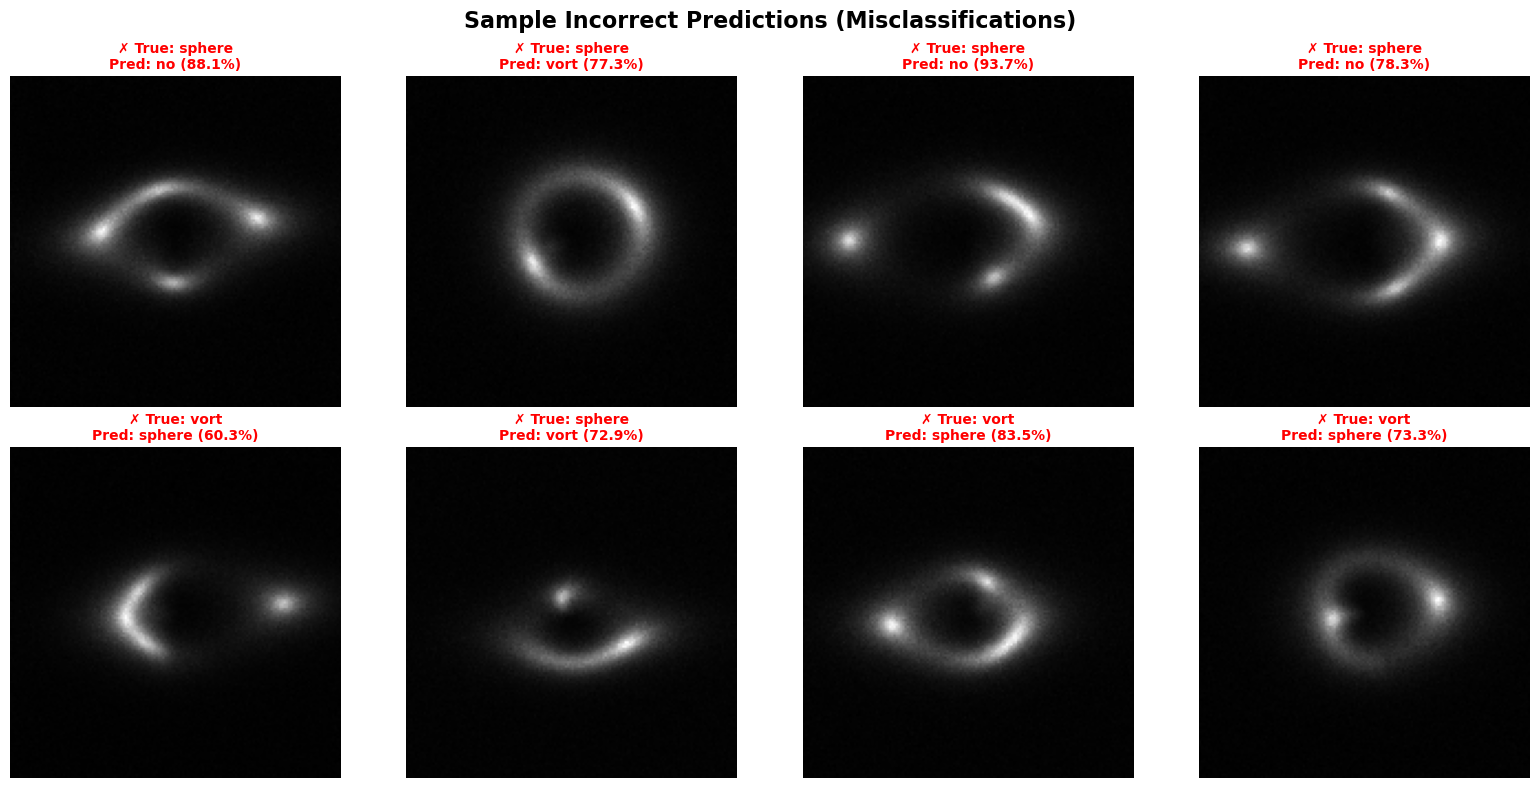

In [18]:
# ============================================================
# CORRECT AND INCORRECT PREDICTIONS VISUALIZATION
# ============================================================

# Find correct and incorrect predictions
correct_mask = test_results['predictions'] == test_results['labels']
incorrect_mask = ~correct_mask

correct_indices = np.where(correct_mask)[0]
incorrect_indices = np.where(incorrect_mask)[0]

print(f"\n📊 Prediction Statistics:")
print(f"   Correct predictions: {len(correct_indices)} ({len(correct_indices)/len(test_results['labels'])*100:.1f}%)")
print(f"   Incorrect predictions: {len(incorrect_indices)} ({len(incorrect_indices)/len(test_results['labels'])*100:.1f}%)")

# Plot some correct predictions
if len(correct_indices) > 0:
    np.random.seed(123)
    sample_correct = np.random.choice(correct_indices, size=min(8, len(correct_indices)), replace=False)
    
    print("\n✅ Sample CORRECT Predictions:")
    plot_predictions_grid(
        [test_results['images'][i] for i in sample_correct],
        test_results['labels'][sample_correct],
        test_results['predictions'][sample_correct],
        test_results['probabilities'][sample_correct],
        classes, num_samples=8, title="Sample Correct Predictions"
    )

# Plot incorrect predictions
if len(incorrect_indices) > 0:
    np.random.seed(456)
    sample_incorrect = np.random.choice(incorrect_indices, size=min(8, len(incorrect_indices)), replace=False)
    
    print("\n❌ Sample INCORRECT Predictions (Misclassifications):")
    plot_predictions_grid(
        [test_results['images'][i] for i in sample_incorrect],
        test_results['labels'][sample_incorrect],
        test_results['predictions'][sample_incorrect],
        test_results['probabilities'][sample_incorrect],
        classes, num_samples=8, title="Sample Incorrect Predictions (Misclassifications)"
    )
else:
    print("\n🎉 No incorrect predictions! Perfect accuracy!")

/tmp/ipykernel_922/286997618.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_to_plot, labels=labels_plot, patch_artist=True)


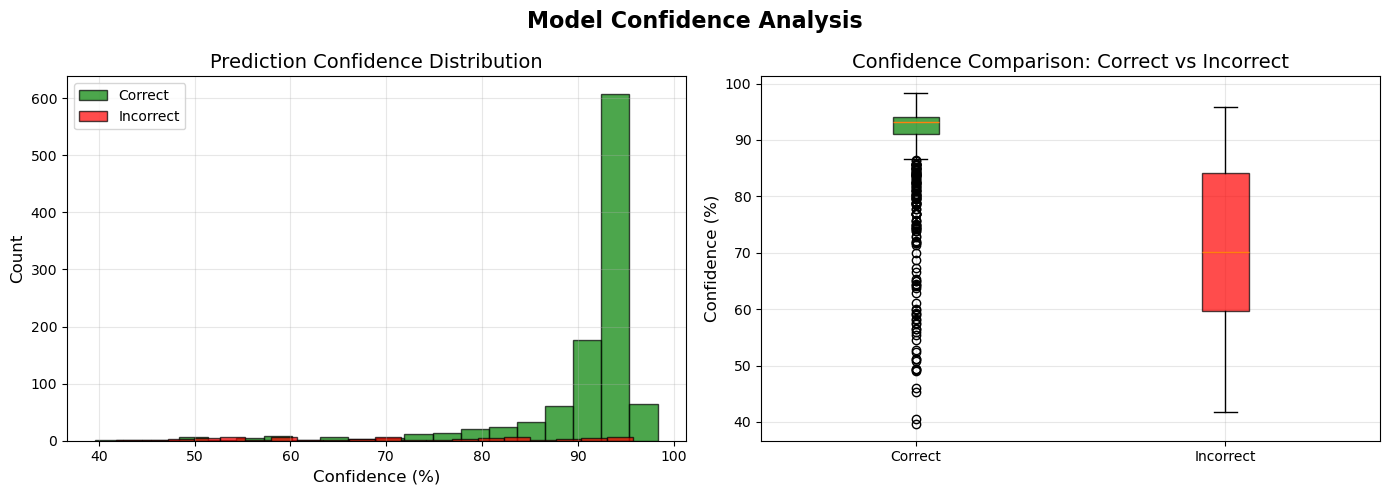


📈 Confidence Statistics:
   Correct predictions - Mean: 90.5%, Median: 93.1%
   Incorrect predictions - Mean: 71.8%, Median: 70.1%


In [19]:
# ============================================================
# CONFIDENCE DISTRIBUTION VISUALIZATION
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Get max confidence for each prediction
max_confidences = test_results['probabilities'].max(axis=1) * 100
correct_confidences = max_confidences[correct_mask]
incorrect_confidences = max_confidences[incorrect_mask]

# Histogram of confidence scores
axes[0].hist(correct_confidences, bins=20, alpha=0.7, label='Correct', color='green', edgecolor='black')
if len(incorrect_confidences) > 0:
    axes[0].hist(incorrect_confidences, bins=20, alpha=0.7, label='Incorrect', color='red', edgecolor='black')
axes[0].set_xlabel('Confidence (%)', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Prediction Confidence Distribution', fontsize=14)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Box plot comparison
data_to_plot = [correct_confidences]
labels_plot = ['Correct']
colors_plot = ['green']

if len(incorrect_confidences) > 0:
    data_to_plot.append(incorrect_confidences)
    labels_plot.append('Incorrect')
    colors_plot.append('red')

bp = axes[1].boxplot(data_to_plot, labels=labels_plot, patch_artist=True)
for patch, color in zip(bp['boxes'], colors_plot):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1].set_ylabel('Confidence (%)', fontsize=12)
axes[1].set_title('Confidence Comparison: Correct vs Incorrect', fontsize=14)
axes[1].grid(alpha=0.3)

plt.suptitle('Model Confidence Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n📈 Confidence Statistics:")
print(f"   Correct predictions - Mean: {correct_confidences.mean():.1f}%, Median: {np.median(correct_confidences):.1f}%")
if len(incorrect_confidences) > 0:
    print(f"   Incorrect predictions - Mean: {incorrect_confidences.mean():.1f}%, Median: {np.median(incorrect_confidences):.1f}%")

In [20]:
# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "="*70)
print("                        FINAL MODEL SUMMARY")
print("="*70)
print(f"\n🏗️  Architecture:")
print(f"    Canonicalization Network: {CONFIG['canon_network']}")
print(f"    Backbone: {CONFIG['backbone']}")
print(f"    Group Type: {CONFIG['group_type']} ({CONFIG['num_rotations']} rotations)")

print(f"\n📊 Dataset:")
print(f"    Training samples: {len(train_loader.dataset)}")
print(f"    Validation samples: {len(val_loader.dataset)}")
print(f"    Test samples: {len(test_loader.dataset)}")
print(f"    Classes: {classes}")

print(f"\n🎯 Performance:")
print(f"    Training Accuracy: {history[-1]['train_acc']:.2f}%")
print(f"    Best Validation Accuracy: {best_acc:.2f}%")
print(f"    Test Accuracy: {test_results['accuracy']:.2f}%")

print(f"\n📈 Per-Class Test Accuracy:")
for i, cls in enumerate(classes):
    print(f"    {cls}: {per_class_acc[i]:.2f}%")

print("\n" + "="*70)
print("                         EVALUATION COMPLETE")
print("="*70)


                        FINAL MODEL SUMMARY

🏗️  Architecture:
    Canonicalization Network: ESCNNEquivariantNetwork
    Backbone: resnet18
    Group Type: rotation (8 rotations)

📊 Dataset:
    Training samples: 30000
    Validation samples: 6375
    Test samples: 1125
    Classes: ['no', 'sphere', 'vort']

🎯 Performance:
    Training Accuracy: 91.52%
    Best Validation Accuracy: 93.96%
    Test Accuracy: 93.96%

📈 Per-Class Test Accuracy:
    no: 97.54%
    sphere: 89.57%
    vort: 95.08%

                         EVALUATION COMPLETE


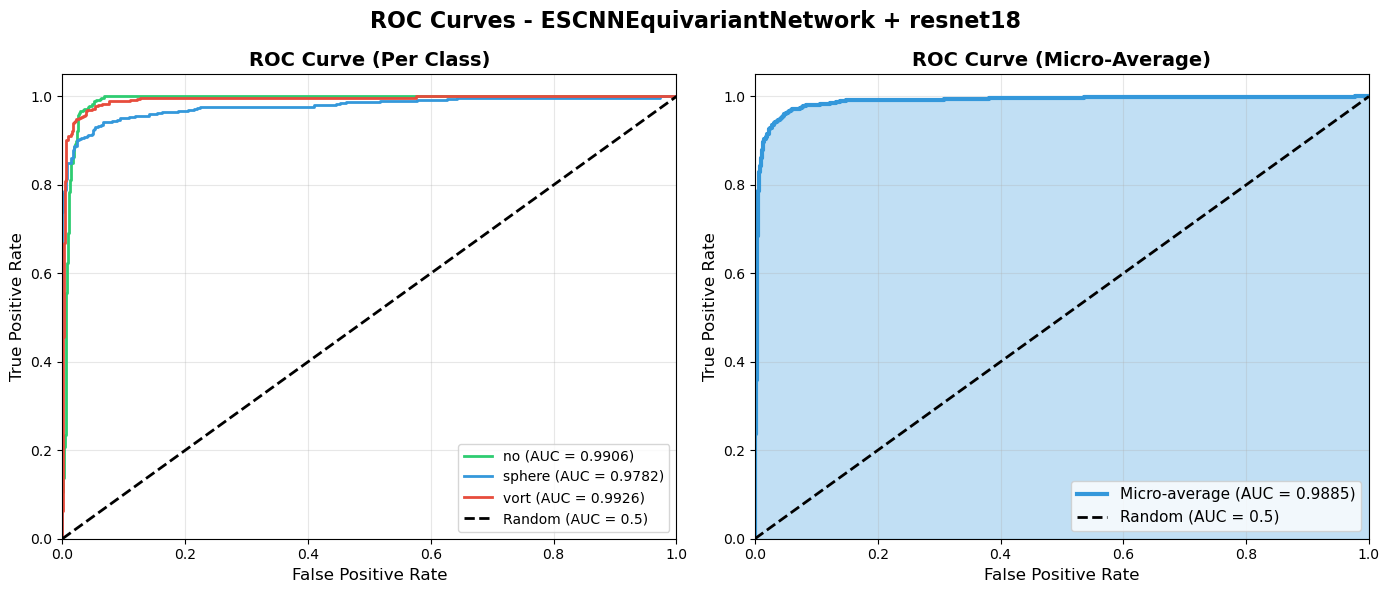


📊 ROC-AUC Summary:
   no: AUC = 0.9906
   sphere: AUC = 0.9782
   vort: AUC = 0.9926
   Micro-average: AUC = 0.9885


In [21]:
# ============================================================
# ROC CURVE VISUALIZATION
# ============================================================

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize labels for multi-class ROC
n_classes = len(classes)
y_true_bin = label_binarize(test_results['labels'], classes=list(range(n_classes)))
y_scores = test_results['probabilities']

# Compute ROC curve and AUC for each class
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_scores[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), y_scores.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot ROC curves
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Individual class ROC curves
colors = ['#2ecc71', '#3498db', '#e74c3c']
for i, (cls, color) in enumerate(zip(classes, colors)):
    axes[0].plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f'{cls} (AUC = {roc_auc[i]:.4f})')

axes[0].plot([0, 1], [0, 1], 'k--', lw=2, label='Random (AUC = 0.5)')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curve (Per Class)', fontsize=14, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=10)
axes[0].grid(alpha=0.3)

# Micro-average ROC with filled area
axes[1].fill_between(fpr["micro"], tpr["micro"], alpha=0.3, color='#3498db')
axes[1].plot(fpr["micro"], tpr["micro"], color='#3498db', lw=3,
             label=f'Micro-average (AUC = {roc_auc["micro"]:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=2, label='Random (AUC = 0.5)')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title('ROC Curve (Micro-Average)', fontsize=14, fontweight='bold')
axes[1].legend(loc='lower right', fontsize=11)
axes[1].grid(alpha=0.3)

plt.suptitle(f'ROC Curves - {CONFIG["canon_network"]} + {CONFIG["backbone"]}', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Print AUC summary
print("\n📊 ROC-AUC Summary:")
print("="*50)
for i, cls in enumerate(classes):
    print(f"   {cls}: AUC = {roc_auc[i]:.4f}")
print(f"   Micro-average: AUC = {roc_auc['micro']:.4f}")
print("="*50)

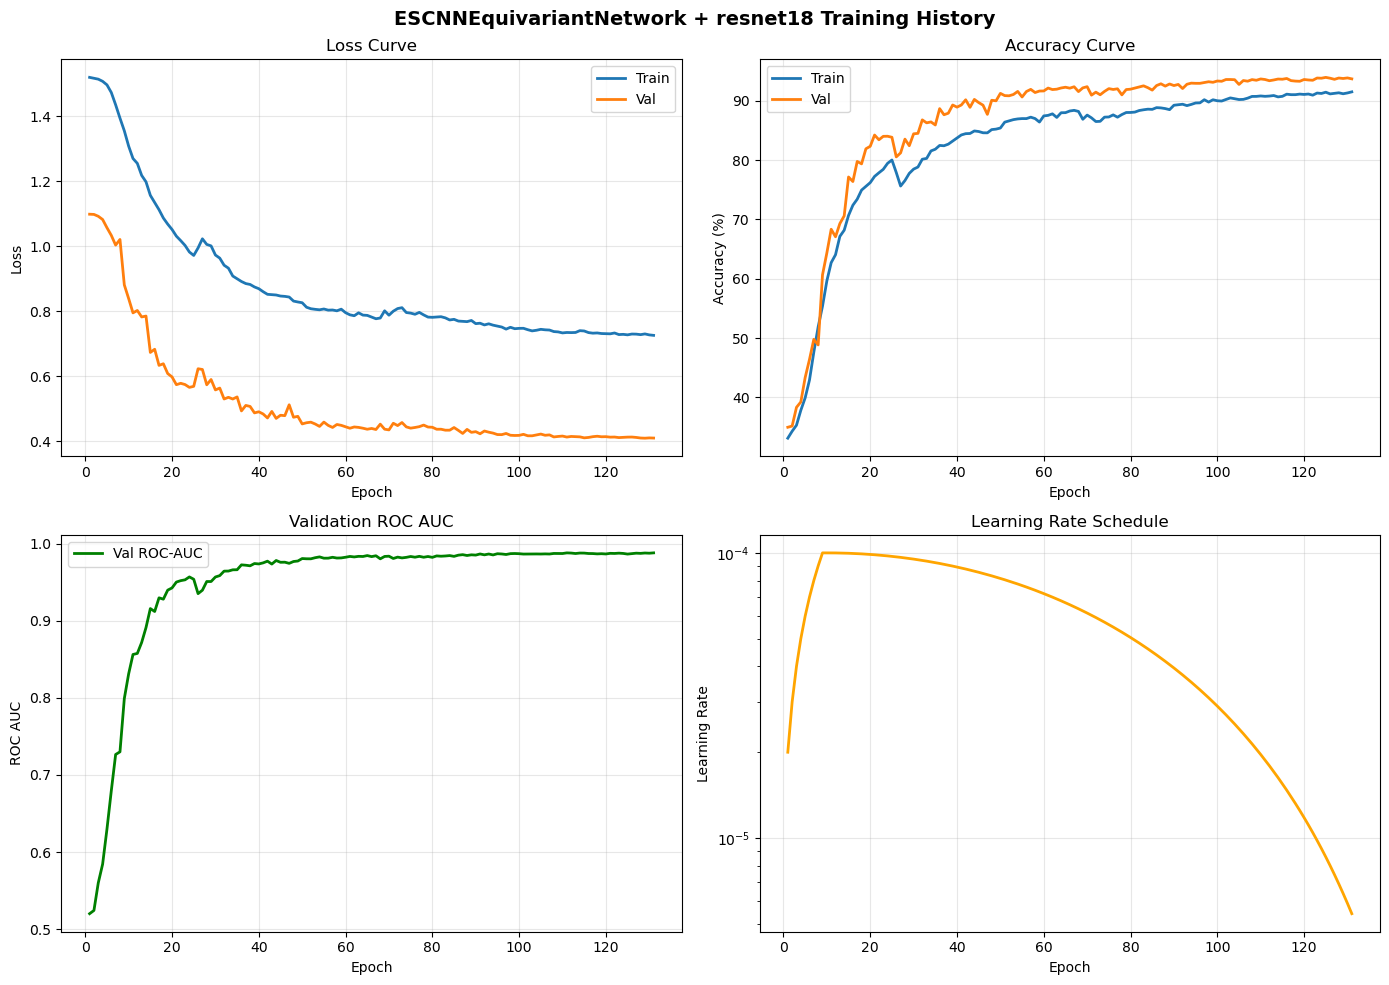


📊 Final Training Statistics:
   Final Train Acc: 91.52%
   Final Val Acc: 93.71%
   Best Val ROC-AUC: 0.9882
   Total Epochs: 131


In [22]:
# ============================================================
# Plot Training History
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

epochs_range = [h['epoch'] for h in history]

# Loss
axes[0, 0].plot(epochs_range, [h['train_loss'] for h in history], label='Train', linewidth=2)
axes[0, 0].plot(epochs_range, [h['val_loss'] for h in history], label='Val', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Loss Curve')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Accuracy
axes[0, 1].plot(epochs_range, [h['train_acc'] for h in history], label='Train', linewidth=2)
axes[0, 1].plot(epochs_range, [h['val_acc'] for h in history], label='Val', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].set_title('Accuracy Curve')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# ROC AUC
axes[1, 0].plot(epochs_range, [h['val_roc_auc'] for h in history], 
                label='Val ROC-AUC', linewidth=2, color='green')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('ROC AUC')
axes[1, 0].set_title('Validation ROC AUC')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Learning Rate
axes[1, 1].plot(epochs_range, [h['lr'] for h in history], linewidth=2, color='orange')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Learning Rate')
axes[1, 1].set_title('Learning Rate Schedule')
axes[1, 1].set_yscale('log')
axes[1, 1].grid(alpha=0.3)

plt.suptitle(f"{CONFIG['canon_network']} + {CONFIG['backbone']} Training History", 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["save_dir"], "training_history.png"), dpi=150)
plt.show()

# Print final stats
print(f"\n📊 Final Training Statistics:")
print(f"   Final Train Acc: {history[-1]['train_acc']:.2f}%")
print(f"   Final Val Acc: {history[-1]['val_acc']:.2f}%")
print(f"   Best Val ROC-AUC: {max(h['val_roc_auc'] for h in history):.4f}")
print(f"   Total Epochs: {len(history)}")